In [2]:
# Cell 1: Import libraries and configure plotting
import os
import json
import warnings
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as sp_stats
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics.pairwise import cosine_distances, euclidean_distances
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")
np.random.seed(42)

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 8)

print("✅ Libraries imported successfully.")

✅ Libraries imported successfully.


In [3]:
# Cell 2: Load dataset and display basic information

# Define paths (adjust if needed)
BASE = os.getcwd()
DATA_PATH = os.path.join(BASE, "mental_health_synthetic_dataset_with_normal.csv")

# Load the data
df = pd.read_csv(DATA_PATH)
print(f"✅ Dataset loaded: {DATA_PATH}")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")

# Show first 5 rows
print("First 5 rows:")
display(df.head())

# Display column names and data types
print("\nColumn data types:")
dtype_info = pd.DataFrame({
    'Column': df.columns,
    'Dtype': df.dtypes.values
})
display(dtype_info)

# Identify column groups (based on naming conventions)
TARGET_COL = "target"
CLASSES = sorted(df[TARGET_COL].unique().tolist())
NUM_COLS = df.select_dtypes(include="number").columns.tolist()
CAT_COLS = [c for c in df.select_dtypes(include="object").columns if c != TARGET_COL]

EMB_COLS = sorted([c for c in NUM_COLS if c.startswith("emb_")])
TOPIC_COLS = sorted([c for c in NUM_COLS if c.startswith("topic_") and c.split("_")[-1].isdigit()])
LING_COLS = [c for c in NUM_COLS if c not in EMB_COLS and c not in TOPIC_COLS]
FEAT_COLS = LING_COLS + TOPIC_COLS

print(f"\nTarget column: {TARGET_COL}")
print(f"Classes: {CLASSES}")
print(f"\nFeature groups:")
print(f"  - Linguistic features: {len(LING_COLS)}")
print(f"  - Topic features:      {len(TOPIC_COLS)}")
print(f"  - Embedding features:  {len(EMB_COLS)}")
print(f"  - Categorical columns: {len(CAT_COLS)}")

✅ Dataset loaded: c:\Users\vicky\OneDrive\Desktop\SCS-projects\Mindspace-voice-agent\mental_health_synthetic_dataset_with_normal.csv
Shape: 50000 rows, 66 columns

First 5 rows:


,profile,language,total_word_count,unique_word_count,ttr,positive_emotion_ratio,negative_emotion_ratio,fear_word_frequency,sadness_word_frequency,anger_word_frequency,...,emb_23,emb_24,emb_25,emb_26,emb_27,emb_28,emb_29,emb_30,emb_31,target
0,Anxiety,marathi,326,106,0.327224,0.029449,0.096709,0.022415,0.022497,0.046256,...,0.152362,1.558506,0.963762,0.973875,-1.044599,0.990256,-2.120762,0.299595,-0.030952,Anxiety
1,Normal,hindi,310,163,0.526694,0.038544,0.007189,0.002901,0.012849,0.008080,...,0.390203,-0.226435,0.657373,-2.401558,-0.378611,-0.438761,-0.915927,0.236808,0.485772,Normal
2,Phobia,english,257,155,0.600898,0.016471,0.027356,0.028057,0.019666,0.003328,...,-0.694345,0.072844,-0.863955,0.567883,-1.347251,0.546552,0.582067,-0.655856,-0.396242,Phobia
3,Bipolar_Mania,hindi,541,317,0.586935,0.037961,0.062862,0.022836,0.040154,0.049701,...,0.836483,-0.768509,-0.192800,-0.791898,-0.110046,0.426967,0.395415,-0.012742,-0.283863,Bipolar_Mania
4,Depression,english,262,162,0.618375,0.012319,0.080076,0.045821,0.065387,0.021260,...,-0.716500,0.101404,0.091508,0.728622,-0.135279,-0.351390,-0.121473,0.802623,-0.023638,Depression



Column data types:


,Column,Dtype
0,profile,object
1,language,object
2,total_word_count,int64
3,unique_word_count,int64
4,ttr,float64
...,...,...
61,emb_28,float64
62,emb_29,float64
63,emb_30,float64
64,emb_31,float64



Target column: target
Classes: ['Anxiety', 'Bipolar_Mania', 'Depression', 'Normal', 'Phobia', 'Stress', 'Suicidal_Tendency']

Feature groups:
  - Linguistic features: 26
  - Topic features:      5
  - Embedding features:  32
  - Categorical columns: 2


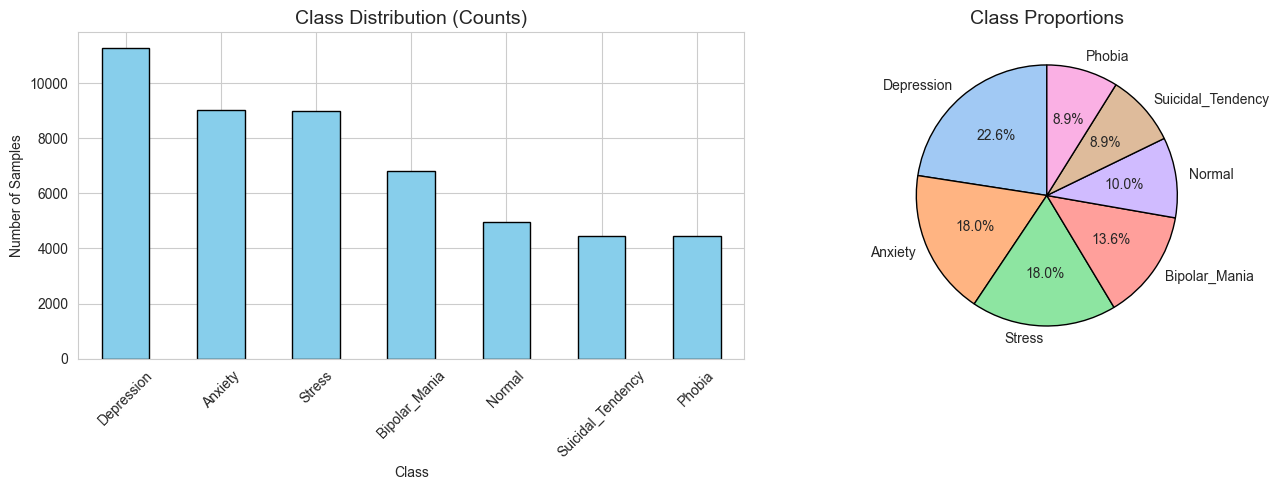


STRUCTURED TEXT SUMMARY
{
  "analysis": "01_dataset_overview_and_class_distribution",
  "dataset": {
    "rows": 50000,
    "columns": 66,
    "target_column": "target",
    "classes": [
      "Anxiety",
      "Bipolar_Mania",
      "Depression",
      "Normal",
      "Phobia",
      "Stress",
      "Suicidal_Tendency"
    ],
    "n_classes": 7,
    "numeric_columns_count": 63,
    "categorical_columns_count": 3,
    "column_dtypes": {
      "profile": "object",
      "language": "object",
      "total_word_count": "int64",
      "unique_word_count": "int64",
      "ttr": "float64",
      "positive_emotion_ratio": "float64",
      "negative_emotion_ratio": "float64",
      "fear_word_frequency": "float64",
      "sadness_word_frequency": "float64",
      "anger_word_frequency": "float64",
      "uncertainty_word_frequency": "float64",
      "filler_word_frequency": "float64",
      "repetition_rate": "float64",
      "rumination_phrase_frequency": "float64",
      "semantic_coherence_

In [4]:
# Cell 3: Dataset Overview & Class Distribution

import json

TARGET_COL = "target"
CLASSES = sorted(df[TARGET_COL].unique().tolist())
N_CLASSES = len(CLASSES)

# ---- Overview ----
rows, cols = df.shape
dtype_map = {col: str(df[col].dtype) for col in df.columns}
null_counts = {col: int(cnt) for col, cnt in df.isnull().sum().items() if cnt > 0}
null_pct = {col: round(cnt / rows * 100, 2) for col, cnt in null_counts.items()}
n_dups = df.duplicated().sum()
memory_mb = round(df.memory_usage(deep=True).sum() / 1024**2, 2)

# ---- Class Distribution ----
counts = df[TARGET_COL].value_counts().sort_values(ascending=False)
props = (counts / rows * 100).round(2)
imbalance = round(counts.max() / counts.min(), 4)
p = (counts / counts.sum()).values
entropy = round(-np.sum(p * np.log2(p + 1e-12)), 4)
max_ent = round(np.log2(N_CLASSES), 4)

# ---- Visualisation ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of class counts
ax = axes[0]
counts.plot(kind='bar', ax=ax, color='skyblue', edgecolor='black')
ax.set_title('Class Distribution (Counts)', fontsize=14)
ax.set_xlabel('Class')
ax.set_ylabel('Number of Samples')
ax.tick_params(axis='x', rotation=45)

# Pie chart of proportions
ax = axes[1]
props.plot(kind='pie', ax=ax, autopct='%1.1f%%', startangle=90, 
           colors=sns.color_palette('pastel'), wedgeprops={'edgecolor': 'black'})
ax.set_title('Class Proportions', fontsize=14)
ax.set_ylabel('')  # hide y-label

plt.tight_layout()
plt.show()

# ---- Structured Text Summary ----
overview_summary = {
    "analysis": "01_dataset_overview_and_class_distribution",
    "dataset": {
        "rows": rows,
        "columns": cols,
        "target_column": TARGET_COL,
        "classes": CLASSES,
        "n_classes": N_CLASSES,
        "numeric_columns_count": len(df.select_dtypes(include='number').columns),
        "categorical_columns_count": len(df.select_dtypes(include='object').columns),
        "column_dtypes": dtype_map,
        "null_counts": null_counts or "none",
        "null_percentages": null_pct or "none",
        "total_null_cells": int(df.isnull().sum().sum()),
        "duplicate_rows": int(n_dups),
        "memory_usage_mb": memory_mb
    },
    "class_distribution": {
        "counts": counts.to_dict(),
        "proportions_percent": props.to_dict(),
        "imbalance_ratio": imbalance,
        "most_frequent_class": str(counts.idxmax()),
        "least_frequent_class": str(counts.idxmin()),
        "shannon_entropy_bits": entropy,
        "max_possible_entropy": max_ent,
        "entropy_percent_of_max": round(entropy / max_ent * 100, 2),
        "note": "100% means perfectly balanced; lower = more skewed"
    }
}

print("\n" + "="*80)
print("STRUCTURED TEXT SUMMARY")
print("="*80)
print(json.dumps(overview_summary, indent=2))

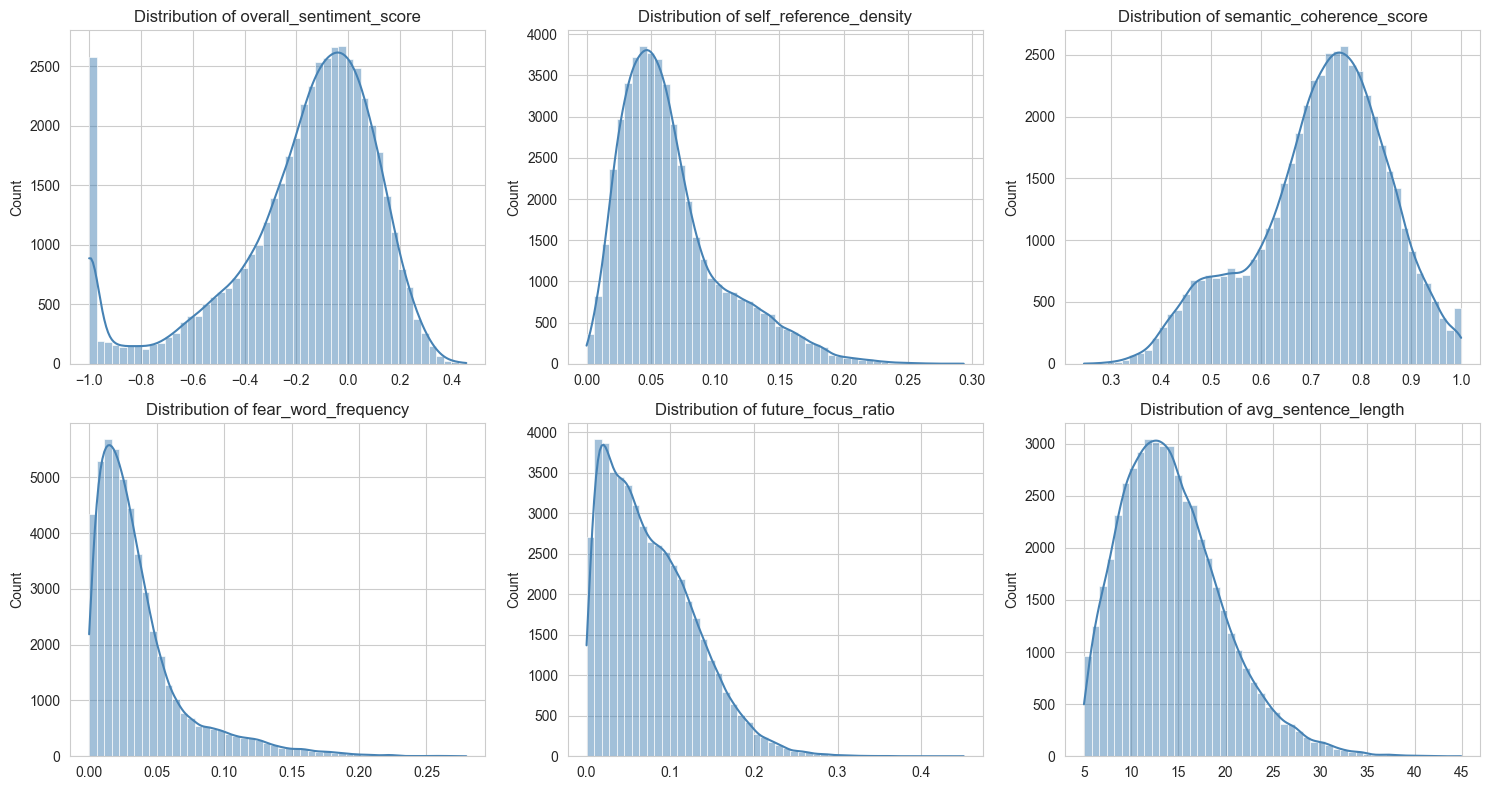


STRUCTURED TEXT SUMMARY
{
  "analysis": "02_descriptive_statistics",
  "description": "Descriptive statistics for all numeric columns: count, mean, std, variance, min, max, percentiles (1,5,10,25,50,75,90,95,99), range, IQR, coefficient of variation (CV%), skewness, excess kurtosis, and mode.",
  "n_numeric_columns": 63,
  "statistics": {
    "total_word_count": {
      "count": 50000,
      "mean": 339.2663,
      "std": 155.439351,
      "variance": 24161.391812,
      "min": 50.0,
      "p1": 74.0,
      "p5": 127.0,
      "p10": 164.0,
      "p25": 235.0,
      "p50": 320.0,
      "p75": 415.0,
      "p90": 527.0,
      "p95": 631.0,
      "p99": 859.01,
      "max": 1459.0,
      "range": 1409.0,
      "iqr": 180.0,
      "cv_pct": 45.8163,
      "skewness": 1.1553,
      "kurtosis": 2.4643,
      "mode": 293.0
    },
    "unique_word_count": {
      "count": 50000,
      "mean": 170.1336,
      "std": 89.39374,
      "variance": 7991.240776,
      "min": 12.0,
      "p1": 33.0,


In [5]:
# Cell 4: Descriptive Statistics for All Numeric Columns

from scipy.stats import skew, kurtosis

NUM_COLS = df.select_dtypes(include='number').columns.tolist()

# ---- Compute statistics ----
desc_stats = {}
for col in NUM_COLS:
    s = df[col].dropna()
    if len(s) == 0:
        continue
    pcts = np.percentile(s, [1, 5, 10, 25, 50, 75, 90, 95, 99])
    desc_stats[col] = {
        "count": int(s.count()),
        "mean": round(float(s.mean()), 6),
        "std": round(float(s.std()), 6),
        "variance": round(float(s.var()), 6),
        "min": round(float(s.min()), 6),
        "p1": round(float(pcts[0]), 6),
        "p5": round(float(pcts[1]), 6),
        "p10": round(float(pcts[2]), 6),
        "p25": round(float(pcts[3]), 6),
        "p50": round(float(pcts[4]), 6),
        "p75": round(float(pcts[5]), 6),
        "p90": round(float(pcts[6]), 6),
        "p95": round(float(pcts[7]), 6),
        "p99": round(float(pcts[8]), 6),
        "max": round(float(s.max()), 6),
        "range": round(float(s.max() - s.min()), 6),
        "iqr": round(float(pcts[5] - pcts[3]), 6),
        "cv_pct": round(float(s.std() / (abs(s.mean()) + 1e-12) * 100), 4),
        "skewness": round(float(skew(s)), 4),
        "kurtosis": round(float(kurtosis(s)), 4),   # excess kurtosis
        "mode": round(float(s.mode().iloc[0]), 6) if len(s.mode()) > 0 else None,
    }

# ---- Visualizations: Select a few representative features ----
# We'll plot histograms + KDE for a subset of linguistic features
features_to_plot = [
    'overall_sentiment_score',
    'self_reference_density',
    'semantic_coherence_score',
    'fear_word_frequency',
    'future_focus_ratio',
    'avg_sentence_length'
]

n_features = len(features_to_plot)
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(features_to_plot):
    if feat in df.columns:
        sns.histplot(df[feat].dropna(), kde=True, ax=axes[i], color='steelblue', bins=50)
        axes[i].set_title(f'Distribution of {feat}')
        axes[i].set_xlabel('')
    else:
        axes[i].set_visible(False)

plt.tight_layout()
plt.show()

# ---- Structured Text Summary ----
desc_summary = {
    "analysis": "02_descriptive_statistics",
    "description": "Descriptive statistics for all numeric columns: count, mean, std, variance, min, max, percentiles (1,5,10,25,50,75,90,95,99), range, IQR, coefficient of variation (CV%), skewness, excess kurtosis, and mode.",
    "n_numeric_columns": len(desc_stats),
    "statistics": desc_stats
}

print("\n" + "="*80)
print("STRUCTURED TEXT SUMMARY")
print("="*80)
print(json.dumps(desc_summary, indent=2))

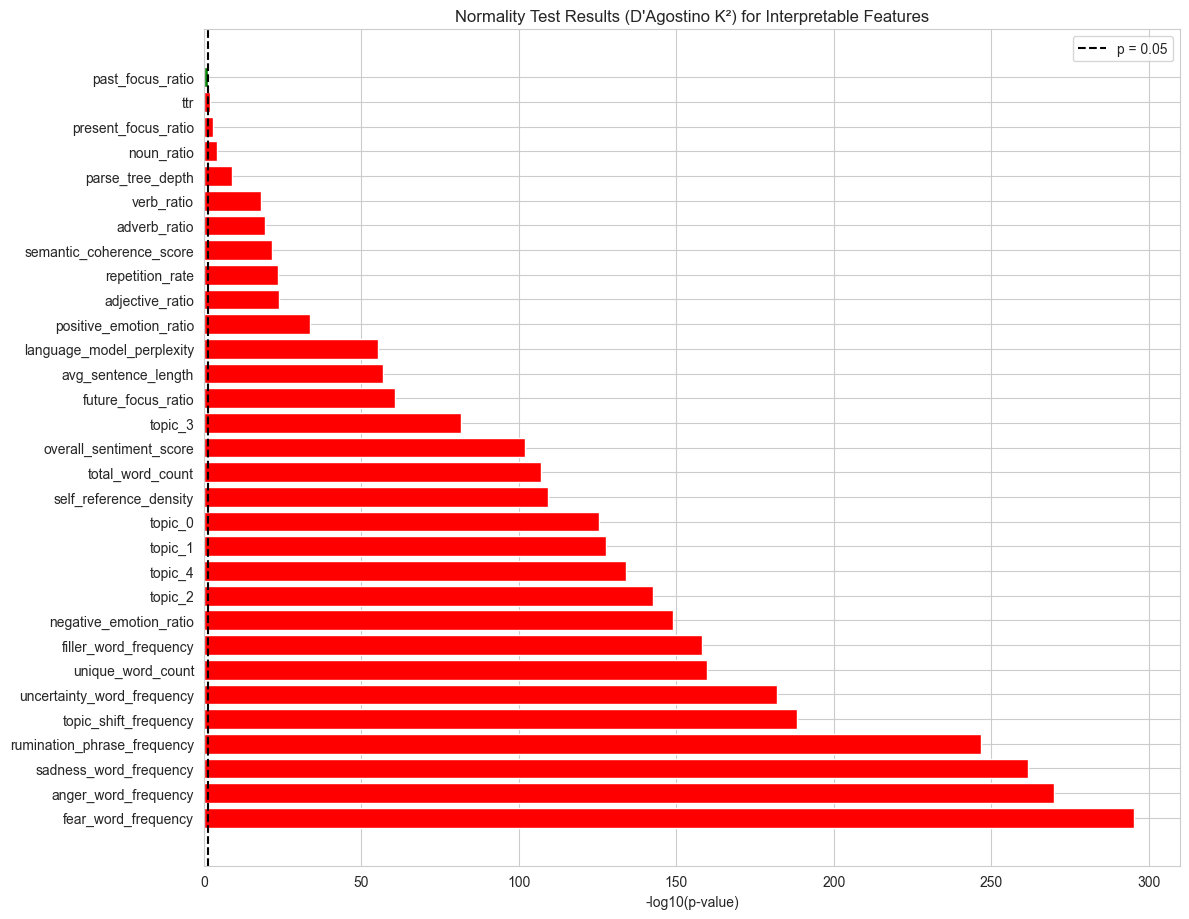


STRUCTURED TEXT SUMMARY
{
  "analysis": "03_normality_tests",
  "test": "D'Agostino K\u00b2 (omnibus test for normality based on skewness and kurtosis)",
  "sample_per_column": 3000,
  "summary": {
    "total_numeric_columns_tested": 63,
    "normal_p05": 32,
    "non_normal_p05": 31
  },
  "results": {
    "total_word_count": {
      "test": "D'Agostino K\u00b2",
      "sample_size": 3000,
      "statistic": 492.3922,
      "p_value": 1.1978485193585724e-107,
      "is_normal_p05": false,
      "skewness": 1.0133,
      "kurtosis": 1.8241
    },
    "unique_word_count": {
      "test": "D'Agostino K\u00b2",
      "sample_size": 3000,
      "statistic": 735.0895,
      "p_value": 2.3841815170756762e-160,
      "is_normal_p05": false,
      "skewness": 1.3017,
      "kurtosis": 2.9634
    },
    "ttr": {
      "test": "D'Agostino K\u00b2",
      "sample_size": 3000,
      "statistic": 9.0979,
      "p_value": 0.010578431466498506,
      "is_normal_p05": false,
      "skewness": 0.0392,

In [6]:
# Cell 5: Normality Tests (D'Agostino K²)

from scipy.stats import normaltest

NORMALITY_SAMPLE = 3000  # rows sampled per column

# Identify interpretable features (linguistic + topic)
INTERP_COLS = LING_COLS + TOPIC_COLS

normality_results = {}
for col in NUM_COLS:
    s = df[col].dropna()
    # sample if too large
    if len(s) > NORMALITY_SAMPLE:
        samp = s.sample(n=NORMALITY_SAMPLE, random_state=42).values
    else:
        samp = s.values
    try:
        stat, pval = normaltest(samp)
        normality_results[col] = {
            "test": "D'Agostino K²",
            "sample_size": len(samp),
            "statistic": round(float(stat), 4),
            "p_value": float(pval),
            "is_normal_p05": bool(pval > 0.05),
            "skewness": round(float(sp_stats.skew(samp)), 4),
            "kurtosis": round(float(sp_stats.kurtosis(samp)), 4),
        }
    except Exception as e:
        normality_results[col] = {"error": str(e)}

# Count how many are normal (p>0.05) among all numeric columns
n_normal = sum(1 for v in normality_results.values() if v.get("is_normal_p05", False))
n_non_normal = len(normality_results) - n_normal

# ---- Visualisation ----
# We'll plot -log10(p-value) for interpretable features (linguistic + topic)
plot_data = []
for col in INTERP_COLS:
    if col in normality_results and 'p_value' in normality_results[col]:
        pv = normality_results[col]['p_value']
        # Avoid log10(0) -> set to a very small value
        log_p = -np.log10(max(pv, 1e-300))
        plot_data.append({'feature': col, 'log10_p': log_p, 'p_value': pv})

df_plot = pd.DataFrame(plot_data).sort_values('log10_p', ascending=False)

plt.figure(figsize=(12, max(6, len(INTERP_COLS)*0.3)))
colors = ['red' if p <= 0.05 else 'green' for p in df_plot['p_value']]
plt.barh(df_plot['feature'], df_plot['log10_p'], color=colors)
plt.axvline(-np.log10(0.05), color='black', linestyle='--', label='p = 0.05')
plt.xlabel('-log10(p-value)')
plt.title('Normality Test Results (D\'Agostino K²) for Interpretable Features')
plt.legend()
plt.tight_layout()
plt.show()

# ---- Structured Text Summary ----
normality_summary = {
    "analysis": "03_normality_tests",
    "test": "D'Agostino K² (omnibus test for normality based on skewness and kurtosis)",
    "sample_per_column": NORMALITY_SAMPLE,
    "summary": {
        "total_numeric_columns_tested": len(normality_results),
        "normal_p05": n_normal,
        "non_normal_p05": n_non_normal,
    },
    "results": normality_results,
    "interpretation_note": "Columns with p > 0.05 are considered approximately normal; those with p ≤ 0.05 deviate from normality."
}

print("\n" + "="*80)
print("STRUCTURED TEXT SUMMARY")
print("="*80)
print(json.dumps(normality_summary, indent=2))

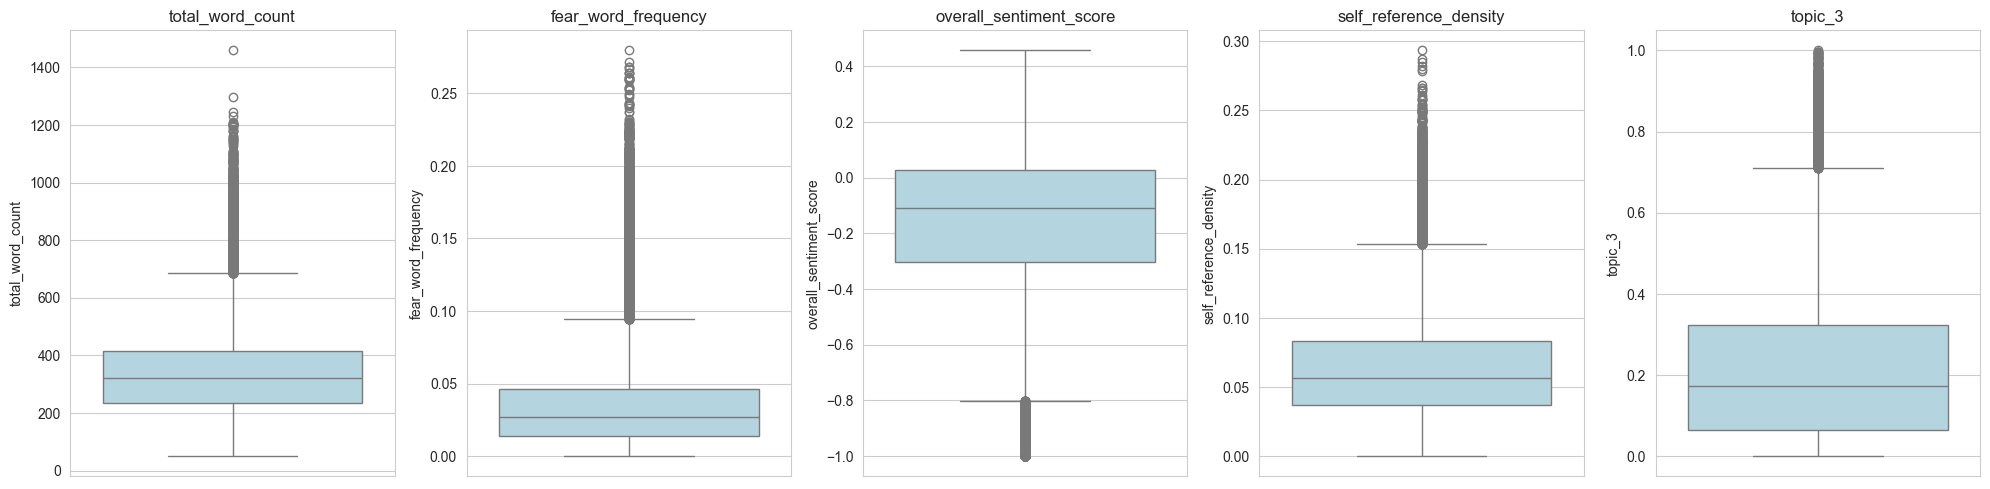


STRUCTURED TEXT SUMMARY
{
  "analysis": "04_outlier_analysis",
  "description": "Outlier detection using IQR (1.5\u00d7IQR rule) and Z\u2011score (|z| > 3).",
  "iqr_multiplier": 1.5,
  "zscore_threshold": 3.0,
  "results": {
    "total_word_count": {
      "iqr_lower_fence": -35.0,
      "iqr_upper_fence": 685.0,
      "iqr_outliers_n": 1797,
      "iqr_outliers_pct": 3.594,
      "zscore_outliers_n": 764,
      "zscore_outliers_pct": 1.528
    },
    "unique_word_count": {
      "iqr_lower_fence": -49.5,
      "iqr_upper_fence": 370.5,
      "iqr_outliers_n": 1645,
      "iqr_outliers_pct": 3.29,
      "zscore_outliers_n": 757,
      "zscore_outliers_pct": 1.514
    },
    "ttr": {
      "iqr_lower_fence": 0.181652,
      "iqr_upper_fence": 0.820457,
      "iqr_outliers_n": 178,
      "iqr_outliers_pct": 0.356,
      "zscore_outliers_n": 64,
      "zscore_outliers_pct": 0.128
    },
    "positive_emotion_ratio": {
      "iqr_lower_fence": -0.025464,
      "iqr_upper_fence": 0.091092

In [7]:
# Cell 6: Outlier Analysis (IQR & Z-score)

OUTLIER_Z_THRESHOLD = 3.0
IQR_MULTIPLIER = 1.5

outlier_results = {}

for col in NUM_COLS:
    s = df[col].dropna()
    if len(s) == 0:
        continue

    # IQR method
    q25, q75 = np.percentile(s, [25, 75])
    iqr = q75 - q25
    lo = q25 - IQR_MULTIPLIER * iqr
    hi = q75 + IQR_MULTIPLIER * iqr
    iqr_outliers = ((s < lo) | (s > hi)).sum()
    iqr_pct = 100 * iqr_outliers / len(s)

    # Z-score method
    mean, std = s.mean(), s.std()
    if std > 0:
        z = np.abs((s - mean) / std)
        z_outliers = (z > OUTLIER_Z_THRESHOLD).sum()
        z_pct = 100 * z_outliers / len(s)
    else:
        z_outliers = 0
        z_pct = 0.0

    outlier_results[col] = {
        "iqr_lower_fence": round(float(lo), 6),
        "iqr_upper_fence": round(float(hi), 6),
        "iqr_outliers_n": int(iqr_outliers),
        "iqr_outliers_pct": round(float(iqr_pct), 3),
        "zscore_outliers_n": int(z_outliers),
        "zscore_outliers_pct": round(float(z_pct), 3),
    }

# ---- Visualisation ----
# Select a few features to show boxplots (with potential outliers)
features_to_plot = [
    'total_word_count',
    'fear_word_frequency',
    'overall_sentiment_score',
    'self_reference_density',
    'topic_3'
]

n_plots = len(features_to_plot)
fig, axes = plt.subplots(nrows=1, ncols=n_plots, figsize=(4*n_plots, 5))
if n_plots == 1:
    axes = [axes]

for ax, feat in zip(axes, features_to_plot):
    if feat in df.columns:
        sns.boxplot(y=df[feat], ax=ax, color='lightblue')
        ax.set_title(feat)
    else:
        ax.set_visible(False)
plt.tight_layout()
plt.show()

# ---- Structured Text Summary ----
outlier_summary = {
    "analysis": "04_outlier_analysis",
    "description": "Outlier detection using IQR (1.5×IQR rule) and Z‑score (|z| > 3).",
    "iqr_multiplier": IQR_MULTIPLIER,
    "zscore_threshold": OUTLIER_Z_THRESHOLD,
    "results": outlier_results
}

print("\n" + "="*80)
print("STRUCTURED TEXT SUMMARY")
print("="*80)
print(json.dumps(outlier_summary, indent=2))

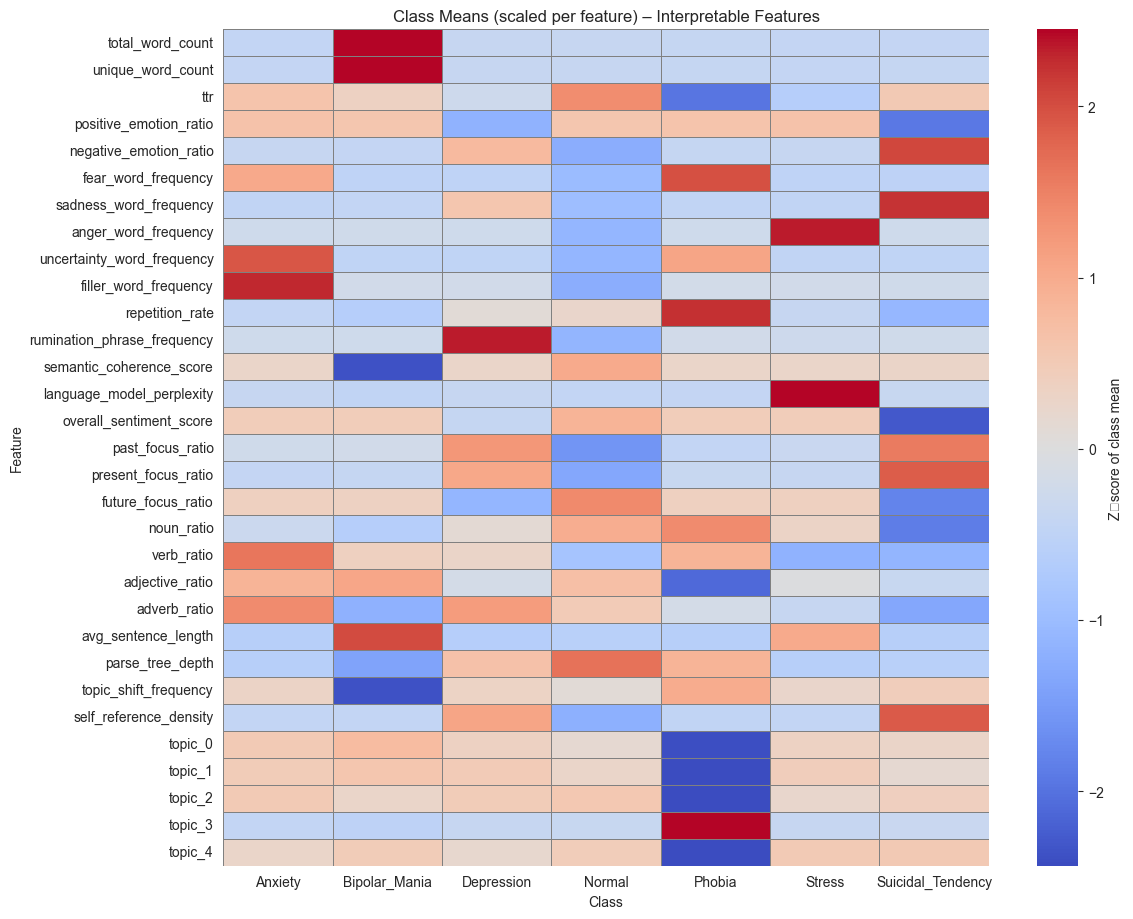


STRUCTURED TEXT SUMMARY
{
  "analysis": "05_per_class_feature_statistics",
  "description": "For each class and each interpretable feature: count, mean, median, std, min, max, 25th/75th percentiles, IQR.",
  "classes": [
    "Anxiety",
    "Bipolar_Mania",
    "Depression",
    "Normal",
    "Phobia",
    "Stress",
    "Suicidal_Tendency"
  ],
  "features": [
    "total_word_count",
    "unique_word_count",
    "ttr",
    "positive_emotion_ratio",
    "negative_emotion_ratio",
    "fear_word_frequency",
    "sadness_word_frequency",
    "anger_word_frequency",
    "uncertainty_word_frequency",
    "filler_word_frequency",
    "repetition_rate",
    "rumination_phrase_frequency",
    "semantic_coherence_score",
    "language_model_perplexity",
    "overall_sentiment_score",
    "past_focus_ratio",
    "present_focus_ratio",
    "future_focus_ratio",
    "noun_ratio",
    "verb_ratio",
    "adjective_ratio",
    "adverb_ratio",
    "avg_sentence_length",
    "parse_tree_depth",
    "top

In [8]:
# Cell 7: Per-Class Feature Statistics

TARGET_COL = "target"
CLASSES = sorted(df[TARGET_COL].unique())
INTERP_COLS = LING_COLS + TOPIC_COLS  # interpretable features

per_class_stats = {}

for cls in CLASSES:
    sub = df[df[TARGET_COL] == cls][INTERP_COLS]
    cls_stats = {}
    for feat in INTERP_COLS:
        s = sub[feat].dropna()
        q25, q75 = np.percentile(s, 25), np.percentile(s, 75)
        cls_stats[feat] = {
            "n": int(len(s)),
            "mean": round(float(s.mean()), 6),
            "median": round(float(s.median()), 6),
            "std": round(float(s.std()), 6),
            "min": round(float(s.min()), 6),
            "max": round(float(s.max()), 6),
            "p25": round(float(q25), 6),
            "p75": round(float(q75), 6),
            "iqr": round(float(q75 - q25), 6),
        }
    per_class_stats[cls] = cls_stats

# ---- Visualisation: Heatmap of class means ----
# Create a DataFrame of means (rows = features, columns = classes)
means_df = pd.DataFrame({cls: {feat: per_class_stats[cls][feat]["mean"] for feat in INTERP_COLS} 
                         for cls in CLASSES})

# Optionally, we can scale each feature (z‑score) to better see deviations
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
means_scaled = pd.DataFrame(
    scaler.fit_transform(means_df.T).T,  # transpose to scale across classes, then back
    index=means_df.index,
    columns=means_df.columns
)

plt.figure(figsize=(12, max(6, len(INTERP_COLS)*0.3)))
sns.heatmap(means_scaled, annot=False, cmap='coolwarm', center=0, 
            linewidths=0.5, linecolor='gray', cbar_kws={'label': 'Z‑score of class mean'})
plt.title('Class Means (scaled per feature) – Interpretable Features')
plt.xlabel('Class')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# ---- Structured Text Summary ----
per_class_summary = {
    "analysis": "05_per_class_feature_statistics",
    "description": "For each class and each interpretable feature: count, mean, median, std, min, max, 25th/75th percentiles, IQR.",
    "classes": CLASSES,
    "features": INTERP_COLS,
    "statistics": per_class_stats
}

print("\n" + "="*80)
print("STRUCTURED TEXT SUMMARY")
print("="*80)
print(json.dumps(per_class_summary, indent=2, default=str))  # default=str handles potential numpy types

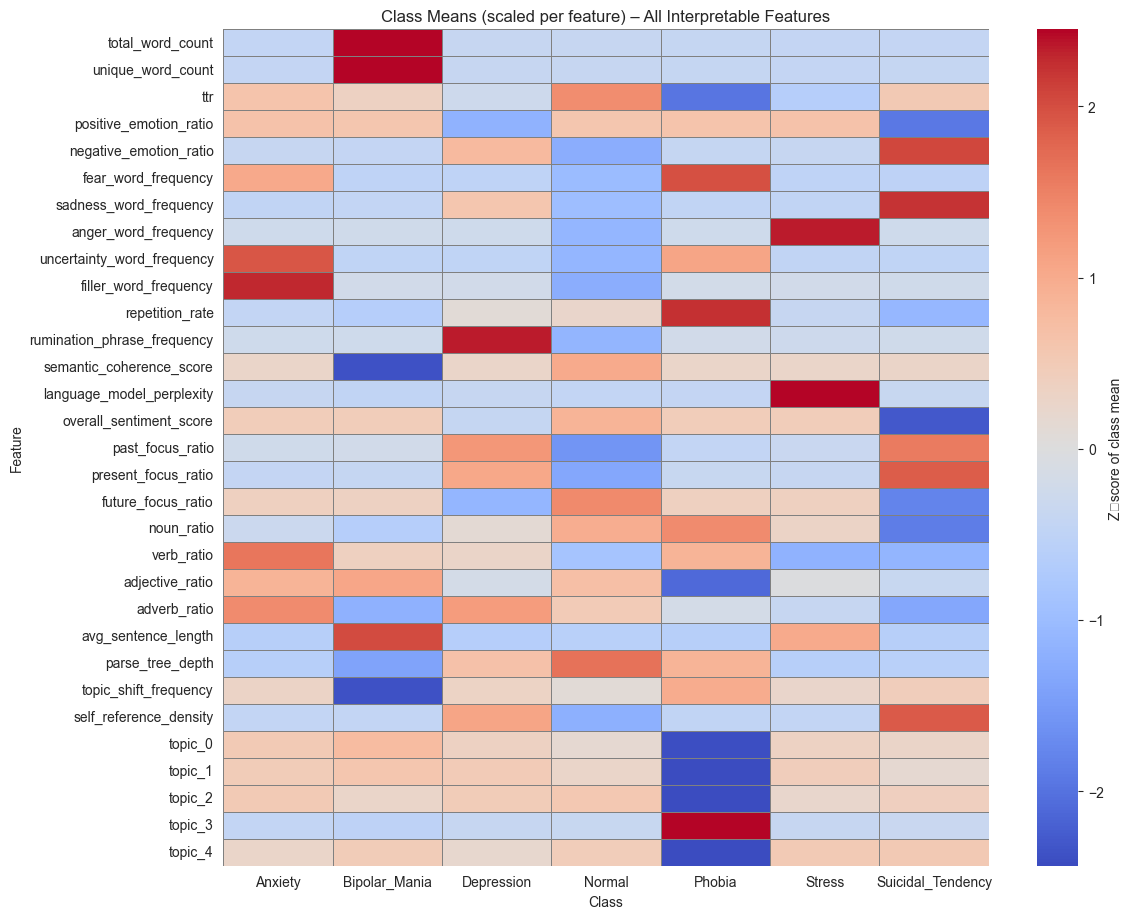


Class means (raw values):


,Anxiety,Bipolar_Mania,Depression,Normal,Phobia,Stress,Suicidal_Tendency
total_word_count,303.3280,552.0092,307.2223,307.6498,306.6296,304.6530,305.4315
unique_word_count,152.3248,277.1057,153.9842,154.3729,153.2381,152.4980,153.4808
ttr,0.5027,0.5026,0.5022,0.5031,0.5013,0.5020,0.5026
positive_emotion_ratio,0.0413,0.0408,0.0207,0.0409,0.0412,0.0414,0.0122
negative_emotion_ratio,0.0534,0.0526,0.0908,0.0265,0.0529,0.0535,0.1313
fear_word_frequency,0.0644,0.0256,0.0256,0.0128,0.0885,0.0257,0.0253
sadness_word_frequency,0.0326,0.0330,0.0652,0.0164,0.0324,0.0327,0.1150
anger_word_frequency,0.0257,0.0258,0.0257,0.0128,0.0256,0.0638,0.0256
uncertainty_word_frequency,0.0827,0.0326,0.0328,0.0197,0.0654,0.0330,0.0329
filler_word_frequency,0.0656,0.0328,0.0330,0.0195,0.0331,0.0328,0.0327


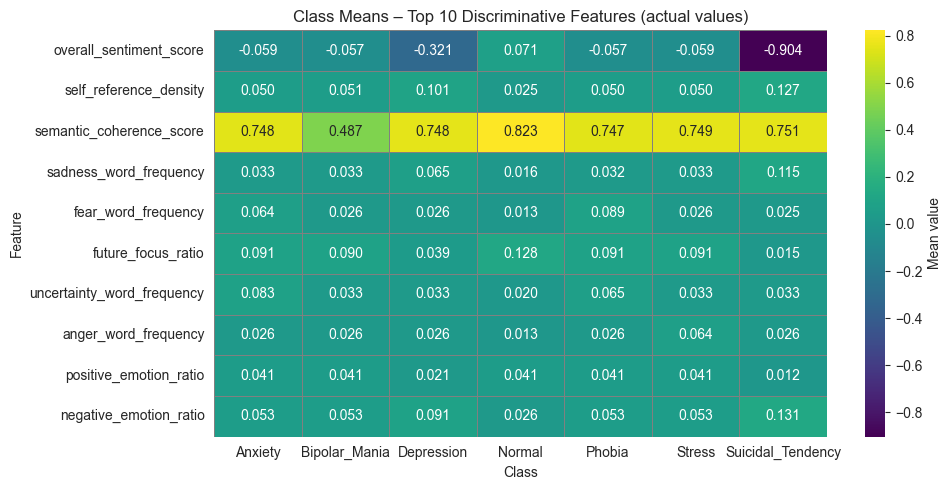


STRUCTURED TEXT SUMMARY
{
  "analysis": "05_per_class_feature_statistics",
  "description": "For each class and each interpretable feature: count, mean, median, std, min, max, 25th/75th percentiles, IQR.",
  "classes": [
    "Anxiety",
    "Bipolar_Mania",
    "Depression",
    "Normal",
    "Phobia",
    "Stress",
    "Suicidal_Tendency"
  ],
  "features": [
    "total_word_count",
    "unique_word_count",
    "ttr",
    "positive_emotion_ratio",
    "negative_emotion_ratio",
    "fear_word_frequency",
    "sadness_word_frequency",
    "anger_word_frequency",
    "uncertainty_word_frequency",
    "filler_word_frequency",
    "repetition_rate",
    "rumination_phrase_frequency",
    "semantic_coherence_score",
    "language_model_perplexity",
    "overall_sentiment_score",
    "past_focus_ratio",
    "present_focus_ratio",
    "future_focus_ratio",
    "noun_ratio",
    "verb_ratio",
    "adjective_ratio",
    "adverb_ratio",
    "avg_sentence_length",
    "parse_tree_depth",
    "top

In [9]:
# Cell 7: Per-Class Feature Statistics (Enhanced)

TARGET_COL = "target"
CLASSES = sorted(df[TARGET_COL].unique())
INTERP_COLS = LING_COLS + TOPIC_COLS  # interpretable features

per_class_stats = {}

for cls in CLASSES:
    sub = df[df[TARGET_COL] == cls][INTERP_COLS]
    cls_stats = {}
    for feat in INTERP_COLS:
        s = sub[feat].dropna()
        q25, q75 = np.percentile(s, 25), np.percentile(s, 75)
        cls_stats[feat] = {
            "n": int(len(s)),
            "mean": round(float(s.mean()), 6),
            "median": round(float(s.median()), 6),
            "std": round(float(s.std()), 6),
            "min": round(float(s.min()), 6),
            "max": round(float(s.max()), 6),
            "p25": round(float(q25), 6),
            "p75": round(float(q75), 6),
            "iqr": round(float(q75 - q25), 6),
        }
    per_class_stats[cls] = cls_stats

# ---- Visualisations ----

# 1. Heatmap of all features (no annotations) – broad overview
means_df = pd.DataFrame({cls: {feat: per_class_stats[cls][feat]["mean"] for feat in INTERP_COLS} 
                         for cls in CLASSES})

# Scale each feature (z‑score across classes) for better colour contrast
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
means_scaled = pd.DataFrame(
    scaler.fit_transform(means_df.T).T,
    index=means_df.index,
    columns=means_df.columns
)

plt.figure(figsize=(12, max(6, len(INTERP_COLS)*0.3)))
sns.heatmap(means_scaled, annot=False, cmap='coolwarm', center=0,
            linewidths=0.5, linecolor='gray', cbar_kws={'label': 'Z‑score of class mean'})
plt.title('Class Means (scaled per feature) – All Interpretable Features')
plt.xlabel('Class')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# 2. Table of class means (actual numbers) – for reading values
print("\nClass means (raw values):")
display(means_df.round(4))

# 3. Annotated heatmap for top 10 most discriminative features
# (Using consensus top 10 from the EDA – we'll define them manually from previous knowledge)
top10_features = [
    'overall_sentiment_score',
    'self_reference_density',
    'semantic_coherence_score',
    'sadness_word_frequency',
    'fear_word_frequency',
    'future_focus_ratio',
    'uncertainty_word_frequency',
    'anger_word_frequency',
    'positive_emotion_ratio',
    'negative_emotion_ratio'
]
# Keep only those that exist in INTERP_COLS
top10_features = [f for f in top10_features if f in INTERP_COLS]

top_means_df = means_df.loc[top10_features] if top10_features else pd.DataFrame()

if not top_means_df.empty:
    plt.figure(figsize=(10, len(top10_features)*0.5))
    sns.heatmap(top_means_df, annot=True, fmt='.3f', cmap='viridis',
                linewidths=0.5, linecolor='gray', cbar_kws={'label': 'Mean value'})
    plt.title('Class Means – Top 10 Discriminative Features (actual values)')
    plt.xlabel('Class')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()
else:
    print("Top 10 features not available for annotation.")

# ---- Structured Text Summary ----
per_class_summary = {
    "analysis": "05_per_class_feature_statistics",
    "description": "For each class and each interpretable feature: count, mean, median, std, min, max, 25th/75th percentiles, IQR.",
    "classes": CLASSES,
    "features": INTERP_COLS,
    "statistics": per_class_stats
}

print("\n" + "="*80)
print("STRUCTURED TEXT SUMMARY")
print("="*80)
print(json.dumps(per_class_summary, indent=2, default=str))

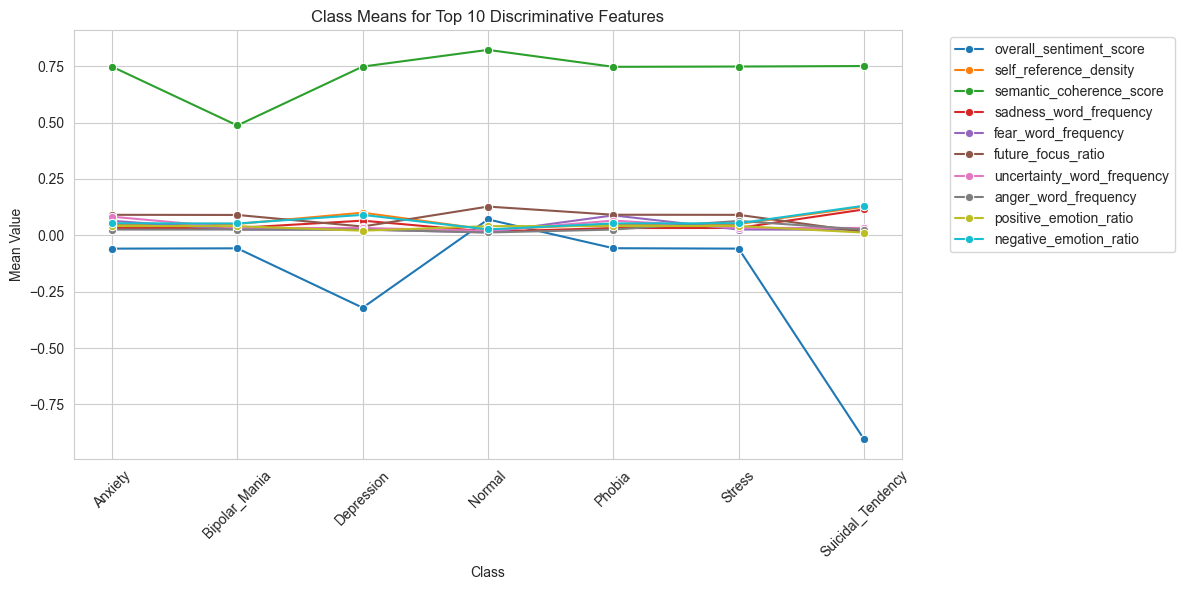


STRUCTURED TEXT SUMMARY
{
  "analysis": "06_feature_class_profile",
  "description": "For each interpretable feature: global mean, median, std, and class\u2011wise means, medians, stds, mins, maxs.",
  "features": [
    "total_word_count",
    "unique_word_count",
    "ttr",
    "positive_emotion_ratio",
    "negative_emotion_ratio",
    "fear_word_frequency",
    "sadness_word_frequency",
    "anger_word_frequency",
    "uncertainty_word_frequency",
    "filler_word_frequency",
    "repetition_rate",
    "rumination_phrase_frequency",
    "semantic_coherence_score",
    "language_model_perplexity",
    "overall_sentiment_score",
    "past_focus_ratio",
    "present_focus_ratio",
    "future_focus_ratio",
    "noun_ratio",
    "verb_ratio",
    "adjective_ratio",
    "adverb_ratio",
    "avg_sentence_length",
    "parse_tree_depth",
    "topic_shift_frequency",
    "self_reference_density",
    "topic_0",
    "topic_1",
    "topic_2",
    "topic_3",
    "topic_4"
  ],
  "profiles": {


In [10]:
# Cell 8: Feature × Class Profile

TARGET_COL = "target"
CLASSES = sorted(df[TARGET_COL].unique())
INTERP_COLS = LING_COLS + TOPIC_COLS

# Build profile dictionary
feat_profile = {}
for feat in INTERP_COLS:
    # Global stats
    global_vals = df[feat].dropna()
    # Class-wise stats
    class_means = df.groupby(TARGET_COL)[feat].mean().round(6).to_dict()
    class_medians = df.groupby(TARGET_COL)[feat].median().round(6).to_dict()
    class_stds = df.groupby(TARGET_COL)[feat].std().round(6).to_dict()
    class_mins = df.groupby(TARGET_COL)[feat].min().round(6).to_dict()
    class_maxs = df.groupby(TARGET_COL)[feat].max().round(6).to_dict()

    feat_profile[feat] = {
        "global_mean": round(float(global_vals.mean()), 6),
        "global_median": round(float(global_vals.median()), 6),
        "global_std": round(float(global_vals.std()), 6),
        "class_means": class_means,
        "class_medians": class_medians,
        "class_stds": class_stds,
        "class_mins": class_mins,
        "class_maxs": class_maxs,
    }

# ---- Visualisation: Line plot for top discriminative features ----
# Use the same top 10 features from earlier
top10_features = [
    'overall_sentiment_score',
    'self_reference_density',
    'semantic_coherence_score',
    'sadness_word_frequency',
    'fear_word_frequency',
    'future_focus_ratio',
    'uncertainty_word_frequency',
    'anger_word_frequency',
    'positive_emotion_ratio',
    'negative_emotion_ratio'
]
# Keep only those present
top10_features = [f for f in top10_features if f in INTERP_COLS]

# Prepare data for plotting
plot_data = []
for feat in top10_features:
    for cls in CLASSES:
        plot_data.append({
            'feature': feat,
            'class': cls,
            'mean': feat_profile[feat]['class_means'][cls]
        })
df_plot = pd.DataFrame(plot_data)

# Create a line plot (one line per feature)
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_plot, x='class', y='mean', hue='feature', marker='o')
plt.title('Class Means for Top 10 Discriminative Features')
plt.xlabel('Class')
plt.ylabel('Mean Value')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ---- Structured Text Summary ----
profile_summary = {
    "analysis": "06_feature_class_profile",
    "description": "For each interpretable feature: global mean, median, std, and class‑wise means, medians, stds, mins, maxs.",
    "features": INTERP_COLS,
    "profiles": feat_profile
}

print("\n" + "="*80)
print("STRUCTURED TEXT SUMMARY")
print("="*80)
print(json.dumps(profile_summary, indent=2, default=str))

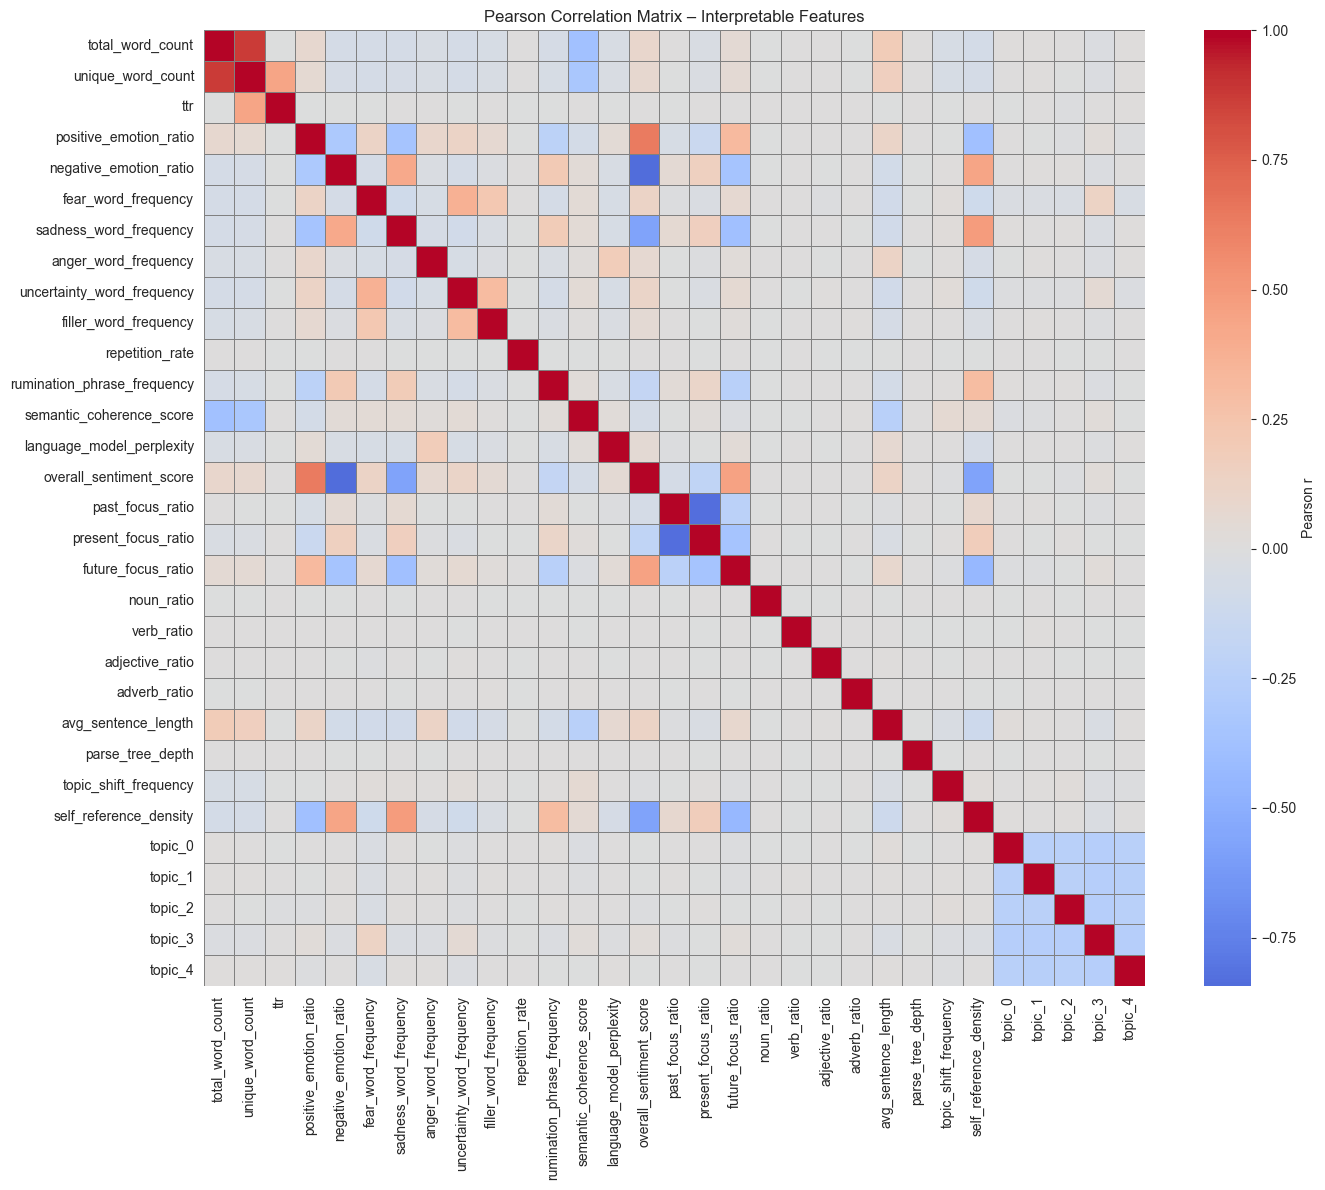


Highly correlated pairs (|r| ≥ 0.75):
  total_word_count ↔ unique_word_count: r = 0.872 (positive)
  negative_emotion_ratio ↔ overall_sentiment_score: r = -0.8438 (negative)
  past_focus_ratio ↔ present_focus_ratio: r = -0.8294 (negative)

STRUCTURED TEXT SUMMARY
{
  "analysis": "07_pearson_correlation",
  "method": "Pearson r",
  "features": [
    "total_word_count",
    "unique_word_count",
    "ttr",
    "positive_emotion_ratio",
    "negative_emotion_ratio",
    "fear_word_frequency",
    "sadness_word_frequency",
    "anger_word_frequency",
    "uncertainty_word_frequency",
    "filler_word_frequency",
    "repetition_rate",
    "rumination_phrase_frequency",
    "semantic_coherence_score",
    "language_model_perplexity",
    "overall_sentiment_score",
    "past_focus_ratio",
    "present_focus_ratio",
    "future_focus_ratio",
    "noun_ratio",
    "verb_ratio",
    "adjective_ratio",
    "adverb_ratio",
    "avg_sentence_length",
    "parse_tree_depth",
    "topic_shift_freque

In [14]:
# Cell 8: Pearson Correlation (interpretable features) + Highly Correlated Pairs

INTERP_COLS = LING_COLS + TOPIC_COLS
CORR_HIGH_THRESHOLD = 0.75

# ---- Pearson matrix ----
pearson = df[INTERP_COLS].corr(method="pearson").round(4)

# ---- Visualisation: heatmap ----
plt.figure(figsize=(14, 12))
sns.heatmap(pearson, annot=False, cmap='coolwarm', center=0,
            linewidths=0.5, linecolor='gray', cbar_kws={'label': 'Pearson r'})
plt.title('Pearson Correlation Matrix – Interpretable Features')
plt.tight_layout()
plt.show()

# ---- Extract highly correlated pairs (|r| >= threshold) ----
pairs = []
for i in range(len(INTERP_COLS)):
    for j in range(i+1, len(INTERP_COLS)):
        val = float(pearson.iloc[i, j])
        if abs(val) >= CORR_HIGH_THRESHOLD:
            pairs.append({
                "feature_1": INTERP_COLS[i],
                "feature_2": INTERP_COLS[j],
                "pearson_r": round(val, 4),
                "abs_r": round(abs(val), 4),
                "direction": "positive" if val > 0 else "negative"
            })
pairs.sort(key=lambda x: -x["abs_r"])

print(f"\nHighly correlated pairs (|r| ≥ {CORR_HIGH_THRESHOLD}):")
for p in pairs:
    print(f"  {p['feature_1']} ↔ {p['feature_2']}: r = {p['pearson_r']} ({p['direction']})")

# ---- Structured Text Summary ----
pearson_summary = {
    "analysis": "07_pearson_correlation",
    "method": "Pearson r",
    "features": INTERP_COLS,
    "matrix": pearson.to_dict(),
    "highly_correlated_pairs": {
        "threshold": CORR_HIGH_THRESHOLD,
        "n_pairs": len(pairs),
        "pairs": pairs
    }
}

print("\n" + "="*80)
print("STRUCTURED TEXT SUMMARY")
print("="*80)
print(json.dumps(pearson_summary, indent=2))

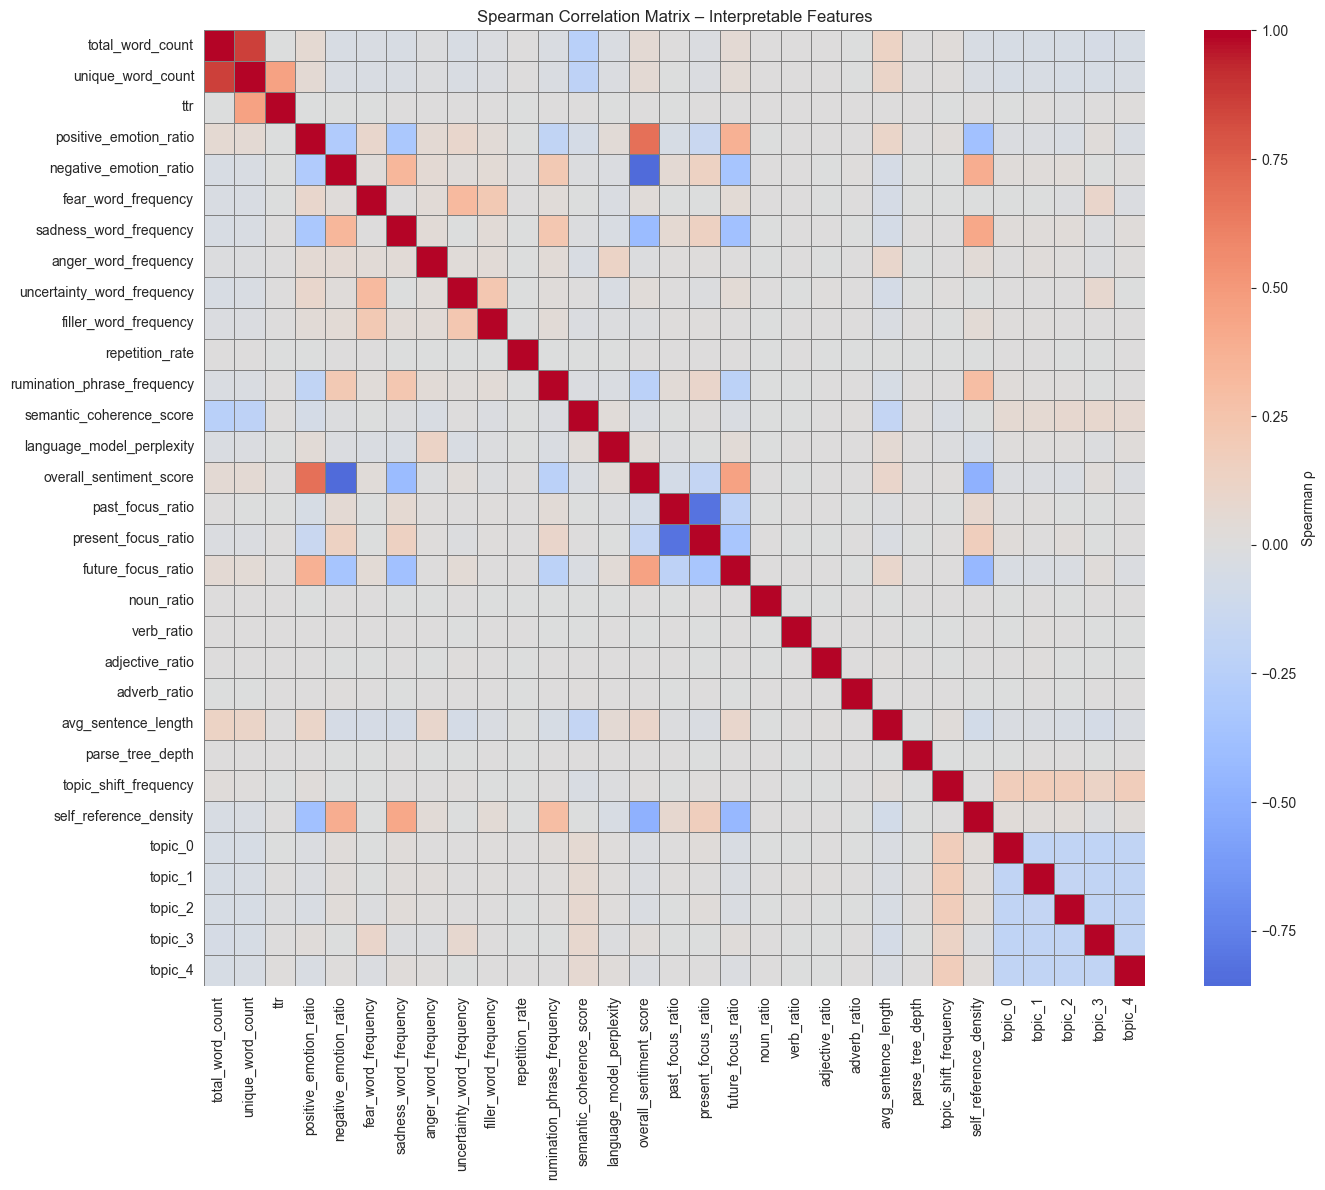


STRUCTURED TEXT SUMMARY
{
  "analysis": "08_spearman_correlation",
  "method": "Spearman rho",
  "features": [
    "total_word_count",
    "unique_word_count",
    "ttr",
    "positive_emotion_ratio",
    "negative_emotion_ratio",
    "fear_word_frequency",
    "sadness_word_frequency",
    "anger_word_frequency",
    "uncertainty_word_frequency",
    "filler_word_frequency",
    "repetition_rate",
    "rumination_phrase_frequency",
    "semantic_coherence_score",
    "language_model_perplexity",
    "overall_sentiment_score",
    "past_focus_ratio",
    "present_focus_ratio",
    "future_focus_ratio",
    "noun_ratio",
    "verb_ratio",
    "adjective_ratio",
    "adverb_ratio",
    "avg_sentence_length",
    "parse_tree_depth",
    "topic_shift_frequency",
    "self_reference_density",
    "topic_0",
    "topic_1",
    "topic_2",
    "topic_3",
    "topic_4"
  ],
  "matrix": {
    "total_word_count": {
      "total_word_count": 1.0,
      "unique_word_count": 0.8612,
      "ttr": -0

In [12]:
# Cell 9: Spearman Correlation (interpretable features)

spearman = df[INTERP_COLS].corr(method="spearman").round(4)

# ---- Visualisation: heatmap ----
plt.figure(figsize=(14, 12))
sns.heatmap(spearman, annot=False, cmap='coolwarm', center=0,
            linewidths=0.5, linecolor='gray', cbar_kws={'label': 'Spearman ρ'})
plt.title('Spearman Correlation Matrix – Interpretable Features')
plt.tight_layout()
plt.show()

# ---- Structured Text Summary ----
spearman_summary = {
    "analysis": "08_spearman_correlation",
    "method": "Spearman rho",
    "features": INTERP_COLS,
    "matrix": spearman.to_dict()
}

print("\n" + "="*80)
print("STRUCTURED TEXT SUMMARY")
print("="*80)
print(json.dumps(spearman_summary, indent=2))

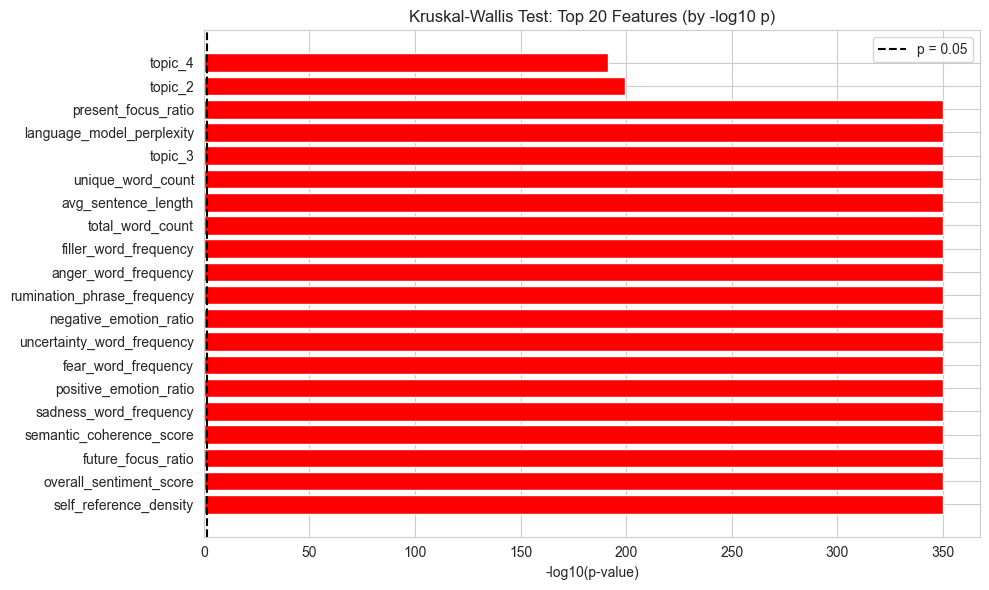


STRUCTURED TEXT SUMMARY
{
  "analysis": "09_kruskal_wallis",
  "test": "Kruskal-Wallis H-test (non-parametric one-way ANOVA)",
  "n_features_tested": 31,
  "n_significant_p05": 24,
  "n_non_significant": 7,
  "significant_features": [
    "total_word_count",
    "unique_word_count",
    "positive_emotion_ratio",
    "negative_emotion_ratio",
    "fear_word_frequency",
    "sadness_word_frequency",
    "anger_word_frequency",
    "uncertainty_word_frequency",
    "filler_word_frequency",
    "rumination_phrase_frequency",
    "semantic_coherence_score",
    "language_model_perplexity",
    "overall_sentiment_score",
    "past_focus_ratio",
    "present_focus_ratio",
    "future_focus_ratio",
    "avg_sentence_length",
    "topic_shift_frequency",
    "self_reference_density",
    "topic_0",
    "topic_1",
    "topic_2",
    "topic_3",
    "topic_4"
  ],
  "non_significant_features": [
    "ttr",
    "repetition_rate",
    "noun_ratio",
    "verb_ratio",
    "adjective_ratio",
    "adve

In [15]:
# Cell 10: Kruskal-Wallis H-Test (each feature vs target)

from scipy.stats import kruskal

CLASSES = sorted(df[TARGET_COL].unique())
kw_results = {}

for feat in INTERP_COLS:
    groups = [df.loc[df[TARGET_COL] == cls, feat].dropna().values for cls in CLASSES]
    if all(len(g) >= 2 for g in groups):
        stat, pval = kruskal(*groups)
        kw_results[feat] = {
            "H_statistic": round(float(stat), 4),
            "p_value": float(pval),
            "significant": bool(pval < 0.05)
        }

# Sort by H-statistic descending
kw_sorted = dict(sorted(kw_results.items(), key=lambda x: -x[1]["H_statistic"]))
sig_feats = [f for f, v in kw_results.items() if v["significant"]]
insig_feats = [f for f, v in kw_results.items() if not v["significant"]]

# ---- Visualisation: bar chart of -log10(p) for top 20 ----
plot_data = []
for feat, res in kw_sorted.items():
    if res['p_value'] > 0:
        logp = -np.log10(max(res['p_value'], 1e-300))
    else:
        logp = 350  # cap for visualisation
    plot_data.append({'feature': feat, 'log10_p': logp, 'p': res['p_value']})

df_plot = pd.DataFrame(plot_data).head(20)

plt.figure(figsize=(10, 6))
colors = ['red' if p <= 0.05 else 'green' for p in df_plot['p']]
plt.barh(df_plot['feature'], df_plot['log10_p'], color=colors)
plt.axvline(-np.log10(0.05), color='black', linestyle='--', label='p = 0.05')
plt.xlabel('-log10(p-value)')
plt.title('Kruskal-Wallis Test: Top 20 Features (by -log10 p)')
plt.legend()
plt.tight_layout()
plt.show()

# ---- Structured Text Summary ----
kw_summary = {
    "analysis": "09_kruskal_wallis",
    "test": "Kruskal-Wallis H-test (non-parametric one-way ANOVA)",
    "n_features_tested": len(kw_results),
    "n_significant_p05": len(sig_feats),
    "n_non_significant": len(insig_feats),
    "significant_features": sig_feats,
    "non_significant_features": insig_feats,
    "results_sorted_by_H": kw_sorted
}

print("\n" + "="*80)
print("STRUCTURED TEXT SUMMARY")
print("="*80)
print(json.dumps(kw_summary, indent=2))

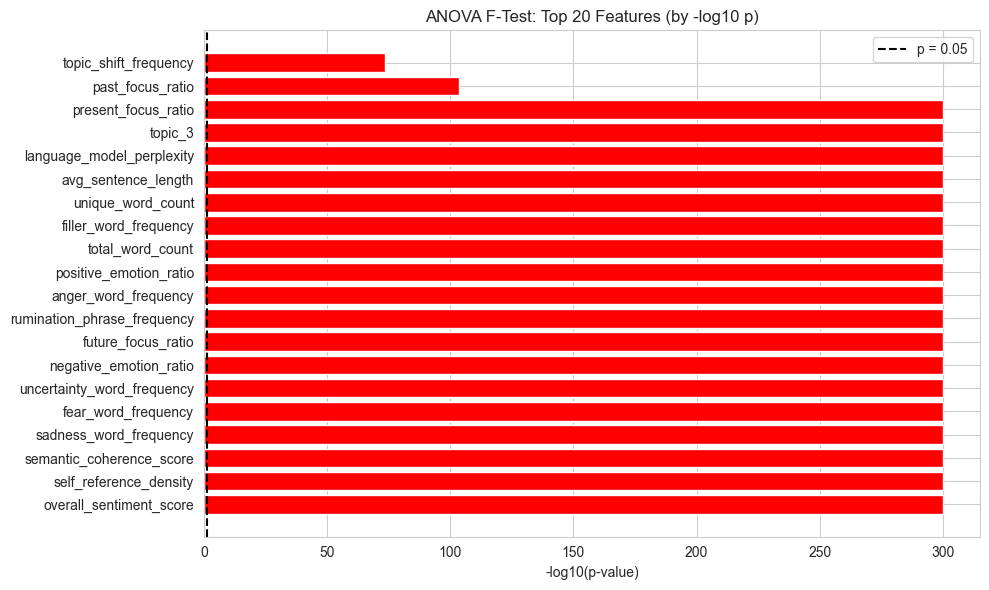


STRUCTURED TEXT SUMMARY
{
  "analysis": "10_anova",
  "test": "One-Way ANOVA (F-test) \u2014 parametric, assumes normality",
  "n_features_tested": 31,
  "n_significant_p05": 25,
  "results": {
    "overall_sentiment_score": {
      "F_statistic": 20261.6632,
      "p_value": 0.0,
      "significant": true
    },
    "self_reference_density": {
      "F_statistic": 9742.128,
      "p_value": 0.0,
      "significant": true
    },
    "semantic_coherence_score": {
      "F_statistic": 8484.5645,
      "p_value": 0.0,
      "significant": true
    },
    "sadness_word_frequency": {
      "F_statistic": 7269.1481,
      "p_value": 0.0,
      "significant": true
    },
    "fear_word_frequency": {
      "F_statistic": 6056.7602,
      "p_value": 0.0,
      "significant": true
    },
    "uncertainty_word_frequency": {
      "F_statistic": 5615.9274,
      "p_value": 0.0,
      "significant": true
    },
    "negative_emotion_ratio": {
      "F_statistic": 4862.8503,
      "p_value": 0.0,
 

In [16]:
# Cell 11: One-Way ANOVA F-Test (each feature vs target)

from scipy.stats import f_oneway

anova_results = {}

for feat in INTERP_COLS:
    groups = [df.loc[df[TARGET_COL] == cls, feat].dropna().values for cls in CLASSES]
    if all(len(g) >= 2 for g in groups):
        f_stat, pval = f_oneway(*groups)
        anova_results[feat] = {
            "F_statistic": round(float(f_stat), 4),
            "p_value": float(pval),
            "significant": bool(pval < 0.05)
        }

# Sort by F-statistic descending
anova_sorted = dict(sorted(anova_results.items(), key=lambda x: -x[1]["F_statistic"]))

# ---- Visualisation: bar chart of -log10(p) for top 20 ----
plot_data = []
for feat, res in anova_sorted.items():
    logp = -np.log10(max(res['p_value'], 1e-300))
    plot_data.append({'feature': feat, 'log10_p': logp, 'p': res['p_value']})

df_plot = pd.DataFrame(plot_data).head(20)

plt.figure(figsize=(10, 6))
colors = ['red' if p <= 0.05 else 'green' for p in df_plot['p']]
plt.barh(df_plot['feature'], df_plot['log10_p'], color=colors)
plt.axvline(-np.log10(0.05), color='black', linestyle='--', label='p = 0.05')
plt.xlabel('-log10(p-value)')
plt.title('ANOVA F-Test: Top 20 Features (by -log10 p)')
plt.legend()
plt.tight_layout()
plt.show()

# ---- Structured Text Summary ----
anova_summary = {
    "analysis": "10_anova",
    "test": "One-Way ANOVA (F-test) — parametric, assumes normality",
    "n_features_tested": len(anova_results),
    "n_significant_p05": sum(1 for v in anova_results.values() if v["significant"]),
    "results": anova_sorted
}

print("\n" + "="*80)
print("STRUCTURED TEXT SUMMARY")
print("="*80)
print(json.dumps(anova_summary, indent=2))

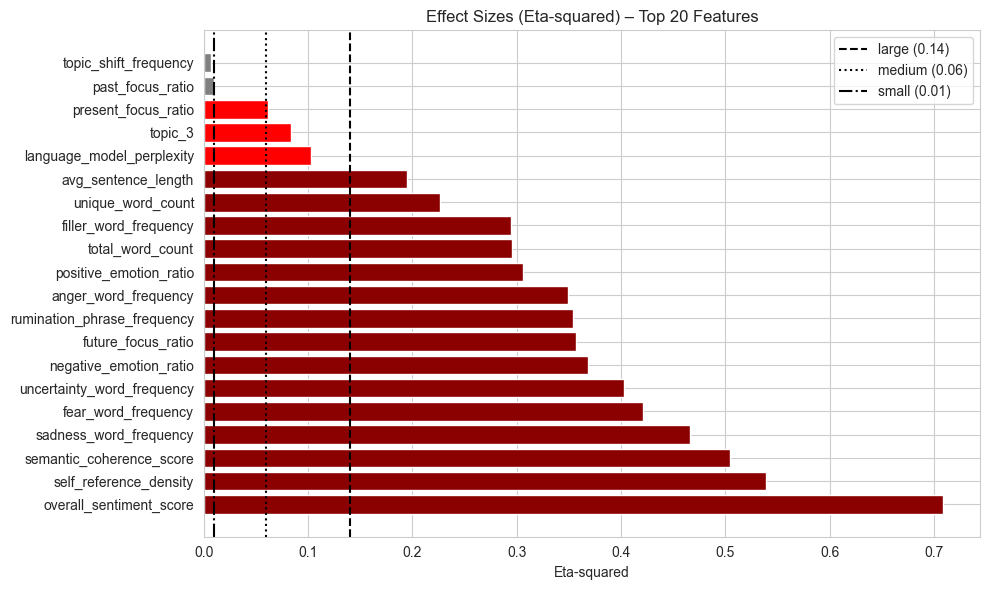


STRUCTURED TEXT SUMMARY
{
  "analysis": "11_eta_squared",
  "description": "Proportion of total feature variance explained by class membership.",
  "benchmarks": {
    "negligible": "<0.01",
    "small": "0.01-0.06",
    "medium": "0.06-0.14",
    "large": ">=0.14"
  },
  "effect_counts": {
    "large": 15,
    "medium": 3,
    "small": 0,
    "negligible": 13
  },
  "results": {
    "overall_sentiment_score": {
      "eta_squared": 0.708603,
      "effect_interpretation": "large"
    },
    "self_reference_density": {
      "eta_squared": 0.539005,
      "effect_interpretation": "large"
    },
    "semantic_coherence_score": {
      "eta_squared": 0.504531,
      "effect_interpretation": "large"
    },
    "sadness_word_frequency": {
      "eta_squared": 0.465932,
      "effect_interpretation": "large"
    },
    "fear_word_frequency": {
      "eta_squared": 0.420932,
      "effect_interpretation": "large"
    },
    "uncertainty_word_frequency": {
      "eta_squared": 0.40263,
     

In [17]:
# Cell 12: Eta-Squared Effect Sizes

def eta_squared(groups):
    """Eta-squared = SS_between / SS_total."""
    all_vals = np.concatenate(groups)
    grand_mean = np.mean(all_vals)
    ss_between = sum(len(g) * (np.mean(g) - grand_mean) ** 2 for g in groups)
    ss_total = np.sum((all_vals - grand_mean) ** 2)
    return float(ss_between / ss_total) if ss_total > 0 else 0.0

def effect_label_eta(e):
    if e >= 0.14:
        return "large"
    elif e >= 0.06:
        return "medium"
    elif e >= 0.01:
        return "small"
    else:
        return "negligible"

eta_results = {}
for feat in INTERP_COLS:
    groups = [df.loc[df[TARGET_COL] == cls, feat].dropna().values for cls in CLASSES]
    if any(len(g) >= 1 for g in groups):
        e2 = eta_squared(groups)
        eta_results[feat] = {
            "eta_squared": round(e2, 6),
            "effect_interpretation": effect_label_eta(e2)
        }

# Sort by eta_squared descending
eta_sorted = dict(sorted(eta_results.items(), key=lambda x: -x[1]["eta_squared"]))

# Count effect sizes
effect_counts = {
    "large": sum(1 for v in eta_results.values() if v["effect_interpretation"] == "large"),
    "medium": sum(1 for v in eta_results.values() if v["effect_interpretation"] == "medium"),
    "small": sum(1 for v in eta_results.values() if v["effect_interpretation"] == "small"),
    "negligible": sum(1 for v in eta_results.values() if v["effect_interpretation"] == "negligible")
}

# ---- Visualisation: horizontal bar chart of eta-squared for top 20 ----
top20_eta = list(eta_sorted.items())[:20]
feats = [x[0] for x in top20_eta]
vals = [x[1]['eta_squared'] for x in top20_eta]
colors = ['darkred' if v >= 0.14 else 'red' if v >= 0.06 else 'orange' if v >= 0.01 else 'gray' for v in vals]

plt.figure(figsize=(10, 6))
plt.barh(feats, vals, color=colors)
plt.axvline(0.14, color='black', linestyle='--', label='large (0.14)')
plt.axvline(0.06, color='black', linestyle=':', label='medium (0.06)')
plt.axvline(0.01, color='black', linestyle='-.', label='small (0.01)')
plt.xlabel('Eta-squared')
plt.title('Effect Sizes (Eta-squared) – Top 20 Features')
plt.legend()
plt.tight_layout()
plt.show()

# ---- Structured Text Summary ----
eta_summary = {
    "analysis": "11_eta_squared",
    "description": "Proportion of total feature variance explained by class membership.",
    "benchmarks": {
        "negligible": "<0.01",
        "small": "0.01-0.06",
        "medium": "0.06-0.14",
        "large": ">=0.14"
    },
    "effect_counts": effect_counts,
    "results": eta_sorted
}

print("\n" + "="*80)
print("STRUCTURED TEXT SUMMARY")
print("="*80)
print(json.dumps(eta_summary, indent=2))

In [18]:
# Cell 13: Pairwise Class Comparisons (Top N features)

from itertools import combinations
from scipy.stats import mannwhitneyu

def cohens_d(a, b):
    na, nb = len(a), len(b)
    if na < 2 or nb < 2:
        return None
    var_a = np.var(a, ddof=1)
    var_b = np.var(b, ddof=1)
    pooled = np.sqrt(((na - 1) * var_a + (nb - 1) * var_b) / (na + nb - 2))
    return float((np.mean(a) - np.mean(b)) / pooled) if pooled > 0 else 0.0

def effect_label_d(d):
    if d is None:
        return None
    abs_d = abs(d)
    if abs_d >= 0.8:
        return "large"
    elif abs_d >= 0.5:
        return "medium"
    elif abs_d >= 0.2:
        return "small"
    else:
        return "negligible"

PAIRWISE_TOP_N = 15
top_features = list(kw_sorted.keys())[:PAIRWISE_TOP_N]
class_pairs = list(combinations(CLASSES, 2))

pairwise_results = {}
for feat in top_features:
    feat_res = {}
    for cls_a, cls_b in class_pairs:
        a = df.loc[df[TARGET_COL] == cls_a, feat].dropna().values
        b = df.loc[df[TARGET_COL] == cls_b, feat].dropna().values
        try:
            u_stat, pval = mannwhitneyu(a, b, alternative='two-sided')
            d = cohens_d(a, b)
            feat_res[f"{cls_a}_vs_{cls_b}"] = {
                "U_statistic": round(float(u_stat), 2),
                "p_value": float(pval),
                "significant_p05": bool(pval < 0.05),
                "cohens_d": round(d, 4) if d is not None else None,
                "effect_size": effect_label_d(d),
                "mean_a": round(float(np.mean(a)), 4),
                "mean_b": round(float(np.mean(b)), 4)
            }
        except Exception as e:
            feat_res[f"{cls_a}_vs_{cls_b}"] = {"error": str(e)}
    pairwise_results[feat] = feat_res

# ---- Structured Text Summary ----
pairwise_summary = {
    "analysis": "12_pairwise_class_comparisons",
    "top_features_tested": top_features,
    "n_class_pairs": len(class_pairs),
    "class_pairs": [f"{a}_vs_{b}" for a, b in class_pairs],
    "test": "Mann-Whitney U (two-sided)",
    "effect_size_metric": "Cohen's d (pooled SD)",
    "results": pairwise_results
}

print("\n" + "="*80)
print("STRUCTURED TEXT SUMMARY")
print("="*80)
print(json.dumps(pairwise_summary, indent=2))


STRUCTURED TEXT SUMMARY
{
  "analysis": "12_pairwise_class_comparisons",
  "top_features_tested": [
    "self_reference_density",
    "overall_sentiment_score",
    "future_focus_ratio",
    "semantic_coherence_score",
    "sadness_word_frequency",
    "positive_emotion_ratio",
    "fear_word_frequency",
    "uncertainty_word_frequency",
    "negative_emotion_ratio",
    "rumination_phrase_frequency",
    "anger_word_frequency",
    "filler_word_frequency",
    "total_word_count",
    "avg_sentence_length",
    "unique_word_count"
  ],
  "n_class_pairs": 21,
  "class_pairs": [
    "Anxiety_vs_Bipolar_Mania",
    "Anxiety_vs_Depression",
    "Anxiety_vs_Normal",
    "Anxiety_vs_Phobia",
    "Anxiety_vs_Stress",
    "Anxiety_vs_Suicidal_Tendency",
    "Bipolar_Mania_vs_Depression",
    "Bipolar_Mania_vs_Normal",
    "Bipolar_Mania_vs_Phobia",
    "Bipolar_Mania_vs_Stress",
    "Bipolar_Mania_vs_Suicidal_Tendency",
    "Depression_vs_Normal",
    "Depression_vs_Phobia",
    "Depression_v

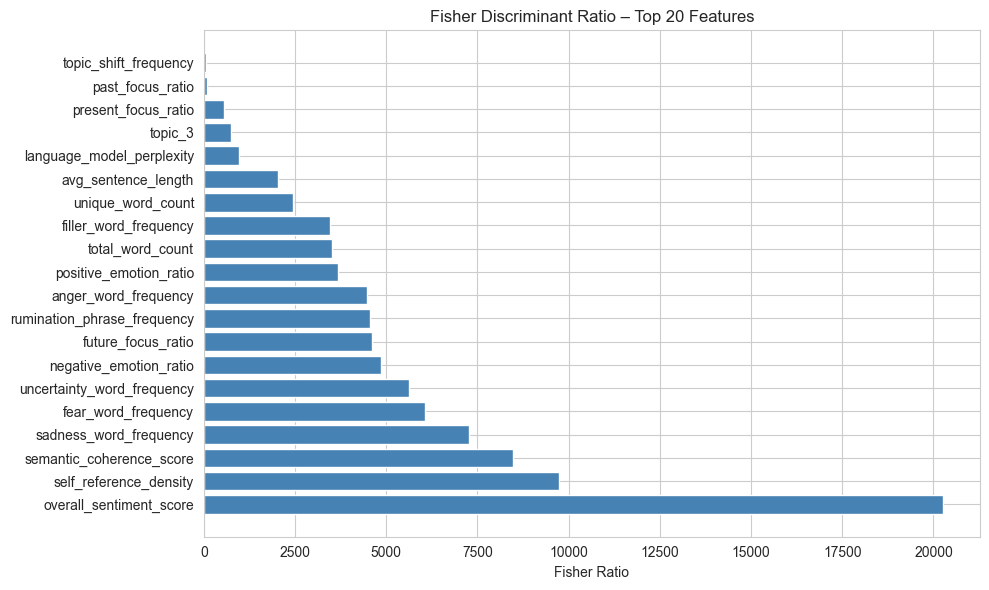


STRUCTURED TEXT SUMMARY
{
  "analysis": "13_fisher_discriminant_ratio",
  "description": "Higher ratio = stronger class separation. Equivalent to the F-statistic in ANOVA.",
  "results": {
    "overall_sentiment_score": {
      "fisher_ratio": 20261.6632,
      "ms_between": 551.2318,
      "ms_within": 0.0272,
      "ss_between": 3307.3905,
      "ss_within": 1360.0921
    },
    "self_reference_density": {
      "fisher_ratio": 9742.128,
      "ms_between": 7.5804,
      "ms_within": 0.0008,
      "ss_between": 45.4824,
      "ss_within": 38.8998
    },
    "semantic_coherence_score": {
      "fisher_ratio": 8484.5645,
      "ms_between": 75.4872,
      "ms_within": 0.0089,
      "ss_between": 452.9232,
      "ss_within": 444.7879
    },
    "sadness_word_frequency": {
      "fisher_ratio": 7269.1481,
      "ms_between": 5.8156,
      "ms_within": 0.0008,
      "ss_between": 34.8936,
      "ss_within": 39.9963
    },
    "fear_word_frequency": {
      "fisher_ratio": 6056.7602,
    

In [19]:
# Cell 14: Fisher Discriminant Ratio (Between-class / Within-class Mean Squares)

N_CLASSES = len(CLASSES)

fisher_results = {}
for feat in INTERP_COLS:
    groups = [df.loc[df[TARGET_COL] == cls, feat].dropna().values for cls in CLASSES]
    all_vals = np.concatenate(groups)
    grand_mean = np.mean(all_vals)
    n_total = len(all_vals)

    # Between-class sum of squares
    ss_between = sum(len(g) * (np.mean(g) - grand_mean) ** 2 for g in groups)
    # Within-class sum of squares
    ss_within = sum(np.sum((g - np.mean(g)) ** 2) for g in groups)

    df_between = N_CLASSES - 1
    df_within = n_total - N_CLASSES
    ms_between = ss_between / df_between if df_between > 0 else 0.0
    ms_within = ss_within / df_within if df_within > 0 else 1e-12

    fisher_ratio = ms_between / ms_within if ms_within > 0 else 0.0

    fisher_results[feat] = {
        "fisher_ratio": round(float(fisher_ratio), 4),
        "ms_between": round(float(ms_between), 4),
        "ms_within": round(float(ms_within), 4),
        "ss_between": round(float(ss_between), 4),
        "ss_within": round(float(ss_within), 4),
    }

# Sort by fisher_ratio descending
fisher_sorted = dict(sorted(fisher_results.items(), key=lambda x: -x[1]["fisher_ratio"]))

# ---- Visualisation: top 20 bar chart ----
top20_fisher = list(fisher_sorted.items())[:20]
feats = [x[0] for x in top20_fisher]
vals = [x[1]['fisher_ratio'] for x in top20_fisher]

plt.figure(figsize=(10, 6))
plt.barh(feats, vals, color='steelblue')
plt.xlabel('Fisher Ratio')
plt.title('Fisher Discriminant Ratio – Top 20 Features')
plt.tight_layout()
plt.show()

# ---- Structured Text Summary ----
fisher_summary = {
    "analysis": "13_fisher_discriminant_ratio",
    "description": "Higher ratio = stronger class separation. Equivalent to the F-statistic in ANOVA.",
    "results": fisher_sorted
}

print("\n" + "="*80)
print("STRUCTURED TEXT SUMMARY")
print("="*80)
print(json.dumps(fisher_summary, indent=2))

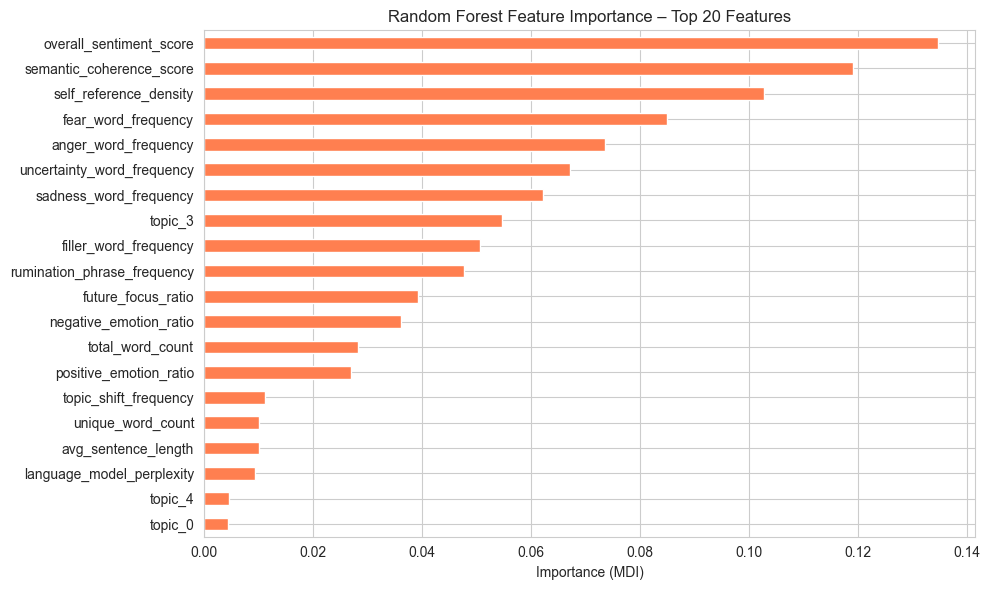


STRUCTURED TEXT SUMMARY
{
  "analysis": "14_random_forest_importance",
  "model": "RandomForestClassifier(n_estimators=150, max_depth=14)",
  "sample_size": 40000,
  "importance_type": "Mean Decrease in Impurity (MDI)",
  "all_importances": {
    "overall_sentiment_score": 0.134803,
    "semantic_coherence_score": 0.11916,
    "self_reference_density": 0.102848,
    "fear_word_frequency": 0.08509,
    "anger_word_frequency": 0.073587,
    "uncertainty_word_frequency": 0.067125,
    "sadness_word_frequency": 0.062234,
    "topic_3": 0.054692,
    "filler_word_frequency": 0.050688,
    "rumination_phrase_frequency": 0.047794,
    "future_focus_ratio": 0.039347,
    "negative_emotion_ratio": 0.036188,
    "total_word_count": 0.028227,
    "positive_emotion_ratio": 0.027049,
    "topic_shift_frequency": 0.011236,
    "unique_word_count": 0.010125,
    "avg_sentence_length": 0.010089,
    "language_model_perplexity": 0.009432,
    "topic_4": 0.004671,
    "topic_0": 0.004427,
    "topic_1"

In [20]:
# Cell 15: Random Forest Feature Importance (Mean Decrease in Impurity)

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

RF_SAMPLE = 40000  # rows to sample for faster training
RF_N_ESTIMATORS = 150

# Prepare target encoding
le = LabelEncoder()
y_all = le.fit_transform(df[TARGET_COL])

# Sample rows
rng = np.random.default_rng(42)
idx = rng.choice(len(df), size=min(RF_SAMPLE, len(df)), replace=False)
X_sample = df.iloc[idx][INTERP_COLS].fillna(df[INTERP_COLS].median())  # fillna just in case
y_sample = y_all[idx]

# Train Random Forest
rf = RandomForestClassifier(
    n_estimators=RF_N_ESTIMATORS,
    max_depth=14,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42,
    class_weight='balanced'
)
rf.fit(X_sample, y_sample)

# Extract importances
rf_imp = pd.Series(rf.feature_importances_, index=INTERP_COLS).sort_values(ascending=False)
top10_rf = rf_imp.head(10).round(6).to_dict()

# ---- Visualisation ----
plt.figure(figsize=(10, 6))
rf_imp.head(20).plot(kind='barh', color='coral')
plt.xlabel('Importance (MDI)')
plt.title('Random Forest Feature Importance – Top 20 Features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# ---- Structured Text Summary ----
rf_summary = {
    "analysis": "14_random_forest_importance",
    "model": f"RandomForestClassifier(n_estimators={RF_N_ESTIMATORS}, max_depth=14)",
    "sample_size": int(len(X_sample)),
    "importance_type": "Mean Decrease in Impurity (MDI)",
    "all_importances": rf_imp.round(6).to_dict(),
    "top_10": top10_rf,
    "top_10_features": list(top10_rf.keys()),
    "classes_order": list(le.classes_)
}

print("\n" + "="*80)
print("STRUCTURED TEXT SUMMARY")
print("="*80)
print(json.dumps(rf_summary, indent=2))

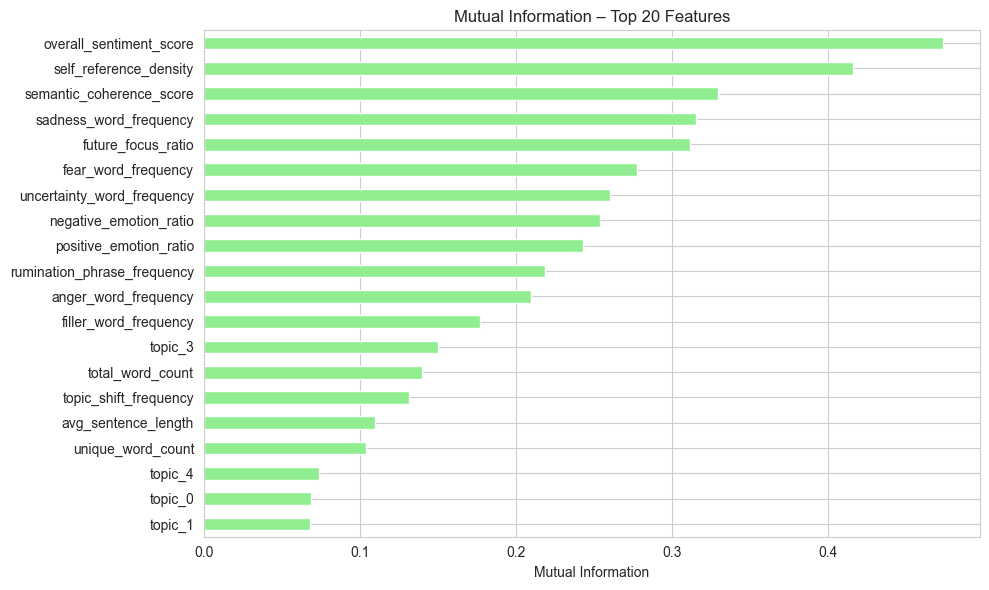


STRUCTURED TEXT SUMMARY
{
  "analysis": "15_mutual_information",
  "description": "Mutual information between each feature and the target label (higher = more informative).",
  "all_scores": {
    "overall_sentiment_score": 0.473484,
    "self_reference_density": 0.416124,
    "semantic_coherence_score": 0.329654,
    "sadness_word_frequency": 0.315045,
    "future_focus_ratio": 0.311525,
    "fear_word_frequency": 0.277147,
    "uncertainty_word_frequency": 0.259887,
    "negative_emotion_ratio": 0.25355,
    "positive_emotion_ratio": 0.242849,
    "rumination_phrase_frequency": 0.218265,
    "anger_word_frequency": 0.209523,
    "filler_word_frequency": 0.177079,
    "topic_3": 0.149878,
    "total_word_count": 0.139625,
    "topic_shift_frequency": 0.131102,
    "avg_sentence_length": 0.109803,
    "unique_word_count": 0.103708,
    "topic_4": 0.073792,
    "topic_0": 0.06838,
    "topic_1": 0.068166,
    "topic_2": 0.065912,
    "language_model_perplexity": 0.05634,
    "present_f

In [21]:
# Cell 16: Mutual Information (each feature vs target)

from sklearn.feature_selection import mutual_info_classif

# Use full dataset (no sampling needed for MI, it's fast)
X_mi = df[INTERP_COLS].fillna(df[INTERP_COLS].median())
mi_scores = mutual_info_classif(X_mi, y_all, discrete_features=False, random_state=42)
mi_series = pd.Series(mi_scores, index=INTERP_COLS).sort_values(ascending=False)
top10_mi = mi_series.head(10).round(6).to_dict()

# ---- Visualisation ----
plt.figure(figsize=(10, 6))
mi_series.head(20).plot(kind='barh', color='lightgreen')
plt.xlabel('Mutual Information')
plt.title('Mutual Information – Top 20 Features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# ---- Structured Text Summary ----
mi_summary = {
    "analysis": "15_mutual_information",
    "description": "Mutual information between each feature and the target label (higher = more informative).",
    "all_scores": mi_series.round(6).to_dict(),
    "top_10": top10_mi,
    "top_10_features": list(top10_mi.keys())
}

print("\n" + "="*80)
print("STRUCTURED TEXT SUMMARY")
print("="*80)
print(json.dumps(mi_summary, indent=2))

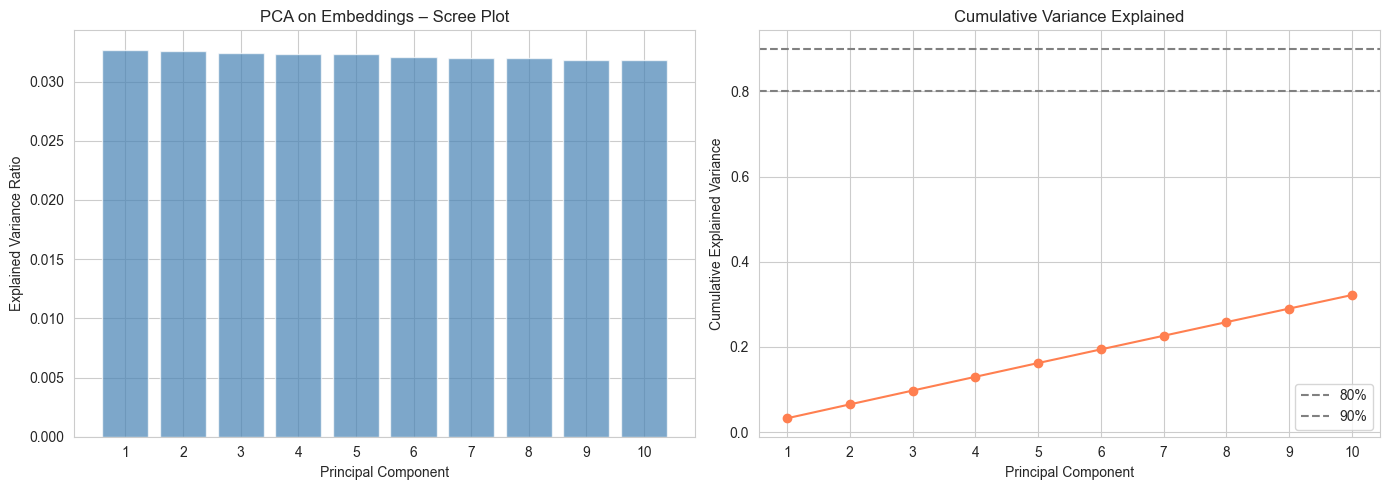


STRUCTURED TEXT SUMMARY
{
  "analysis": "16_pca_embeddings",
  "n_embedding_features": 32,
  "n_components_analysed": 10,
  "explained_variance_ratio": [
    0.0327,
    0.0326,
    0.0324,
    0.0323,
    0.0323,
    0.0321,
    0.032,
    0.032,
    0.0318,
    0.0318
  ],
  "cumulative_variance_ratio": [
    0.0327,
    0.0653,
    0.0977,
    0.13,
    0.1623,
    0.1943,
    0.2264,
    0.2583,
    0.2901,
    0.3219
  ],
  "total_variance_top_k_pct": 32.19,
  "components_for_80pct": null,
  "components_for_90pct": null,
  "per_component": [
    {
      "component": 1,
      "variance_explained_pct": 3.268,
      "cumulative_pct": 3.268
    },
    {
      "component": 2,
      "variance_explained_pct": 3.257,
      "cumulative_pct": 6.526
    },
    {
      "component": 3,
      "variance_explained_pct": 3.242,
      "cumulative_pct": 9.768
    },
    {
      "component": 4,
      "variance_explained_pct": 3.233,
      "cumulative_pct": 13.0
    },
    {
      "component": 5,
   

In [22]:
# Cell 17: PCA on Embedding Features

from sklearn.decomposition import PCA

if EMB_COLS:
    # Prepare embedding data (fill with 0 as they are standardized already)
    X_emb = df[EMB_COLS].fillna(0).values
    n_comp = min(10, len(EMB_COLS))
    pca_emb = PCA(n_components=n_comp, random_state=42)
    pca_emb.fit(X_emb)

    evr = pca_emb.explained_variance_ratio_
    cum_evr = np.cumsum(evr)

    # ---- Visualisation: scree plot ----
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Bar plot of explained variance
    axes[0].bar(range(1, n_comp+1), evr, alpha=0.7, color='steelblue')
    axes[0].set_xlabel('Principal Component')
    axes[0].set_ylabel('Explained Variance Ratio')
    axes[0].set_title('PCA on Embeddings – Scree Plot')
    axes[0].set_xticks(range(1, n_comp+1))

    # Cumulative line
    axes[1].plot(range(1, n_comp+1), cum_evr, 'o-', color='coral')
    axes[1].set_xlabel('Principal Component')
    axes[1].set_ylabel('Cumulative Explained Variance')
    axes[1].set_title('Cumulative Variance Explained')
    axes[1].set_xticks(range(1, n_comp+1))
    axes[1].axhline(y=0.8, linestyle='--', color='gray', label='80%')
    axes[1].axhline(y=0.9, linestyle='--', color='gray', label='90%')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    # Determine components needed for 80% and 90% variance
    comp_80 = int(np.argmax(cum_evr >= 0.80) + 1) if any(cum_evr >= 0.80) else None
    comp_90 = int(np.argmax(cum_evr >= 0.90) + 1) if any(cum_evr >= 0.90) else None

    # ---- Structured Text Summary ----
    pca_emb_summary = {
        "analysis": "16_pca_embeddings",
        "n_embedding_features": len(EMB_COLS),
        "n_components_analysed": n_comp,
        "explained_variance_ratio": [round(float(v), 4) for v in evr],
        "cumulative_variance_ratio": [round(float(v), 4) for v in cum_evr],
        "total_variance_top_k_pct": round(float(cum_evr[-1] * 100), 2),
        "components_for_80pct": comp_80,
        "components_for_90pct": comp_90,
        "per_component": [
            {
                "component": i+1,
                "variance_explained_pct": round(float(evr[i] * 100), 3),
                "cumulative_pct": round(float(cum_evr[i] * 100), 3)
            }
            for i in range(n_comp)
        ]
    }
else:
    pca_emb_summary = {
        "analysis": "16_pca_embeddings",
        "note": "No embedding columns found."
    }

print("\n" + "="*80)
print("STRUCTURED TEXT SUMMARY")
print("="*80)
print(json.dumps(pca_emb_summary, indent=2))

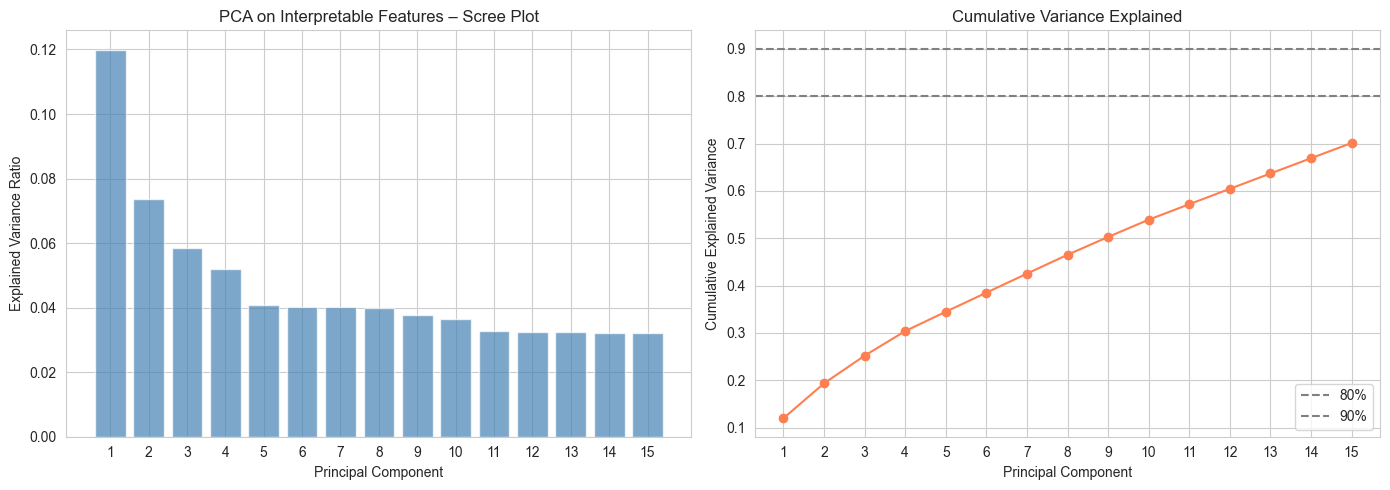


STRUCTURED TEXT SUMMARY
{
  "analysis": "17_pca_interpretable_features",
  "n_features": 31,
  "n_components_analysed": 15,
  "scaling": "StandardScaler (zero mean, unit variance)",
  "explained_variance_ratio": [
    0.1199,
    0.0737,
    0.0585,
    0.0519,
    0.0409,
    0.0403,
    0.0402,
    0.0399,
    0.0376,
    0.0365,
    0.0327,
    0.0326,
    0.0323,
    0.0323,
    0.0321
  ],
  "cumulative_variance_ratio": [
    0.1199,
    0.1936,
    0.2521,
    0.3039,
    0.3448,
    0.3851,
    0.4253,
    0.4652,
    0.5028,
    0.5393,
    0.5719,
    0.6045,
    0.6368,
    0.6691,
    0.7012
  ],
  "components_for_80pct": null,
  "components_for_90pct": null,
  "top_5_loadings_per_pc": {
    "PC1": {
      "overall_sentiment_score": 0.4609,
      "negative_emotion_ratio": -0.3841,
      "self_reference_density": -0.3819,
      "sadness_word_frequency": -0.3587,
      "positive_emotion_ratio": 0.3409
    },
    "PC2": {
      "unique_word_count": 0.5765,
      "total_word_co

In [23]:
# Cell 18: PCA on Interpretable Features (scaled)

from sklearn.preprocessing import StandardScaler

# Prepare data
X_feat = df[INTERP_COLS].fillna(df[INTERP_COLS].median()).values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_feat)

n_comp = min(15, len(INTERP_COLS))
pca_feat = PCA(n_components=n_comp, random_state=42)
pca_feat.fit(X_scaled)

evr_feat = pca_feat.explained_variance_ratio_
cum_feat = np.cumsum(evr_feat)

# ---- Visualisation: scree plot ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(range(1, n_comp+1), evr_feat, alpha=0.7, color='steelblue')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('PCA on Interpretable Features – Scree Plot')
axes[0].set_xticks(range(1, n_comp+1))

axes[1].plot(range(1, n_comp+1), cum_feat, 'o-', color='coral')
axes[1].set_xlabel('Principal Component')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Variance Explained')
axes[1].set_xticks(range(1, n_comp+1))
axes[1].axhline(y=0.8, linestyle='--', color='gray', label='80%')
axes[1].axhline(y=0.9, linestyle='--', color='gray', label='90%')
axes[1].legend()
plt.tight_layout()
plt.show()

# Top loadings per component (top 5 features by absolute weight)
loadings = pd.DataFrame(
    pca_feat.components_,
    columns=INTERP_COLS,
    index=[f"PC{i+1}" for i in range(n_comp)]
)
top_loadings = {}
for pc in loadings.index:
    row = loadings.loc[pc].abs().sort_values(ascending=False)
    top_loadings[pc] = {feat: round(float(loadings.loc[pc, feat]), 4) for feat in row.head(5).index}

# Components needed for 80% and 90% variance
comp_80_feat = int(np.argmax(cum_feat >= 0.80) + 1) if any(cum_feat >= 0.80) else None
comp_90_feat = int(np.argmax(cum_feat >= 0.90) + 1) if any(cum_feat >= 0.90) else None

# ---- Structured Text Summary ----
pca_feat_summary = {
    "analysis": "17_pca_interpretable_features",
    "n_features": len(INTERP_COLS),
    "n_components_analysed": n_comp,
    "scaling": "StandardScaler (zero mean, unit variance)",
    "explained_variance_ratio": [round(float(v), 4) for v in evr_feat],
    "cumulative_variance_ratio": [round(float(v), 4) for v in cum_feat],
    "components_for_80pct": comp_80_feat,
    "components_for_90pct": comp_90_feat,
    "top_5_loadings_per_pc": top_loadings,
    "per_component": [
        {
            "component": i+1,
            "variance_explained_pct": round(float(evr_feat[i] * 100), 3),
            "cumulative_pct": round(float(cum_feat[i] * 100), 3)
        }
        for i in range(n_comp)
    ]
}

print("\n" + "="*80)
print("STRUCTURED TEXT SUMMARY")
print("="*80)
print(json.dumps(pca_feat_summary, indent=2))

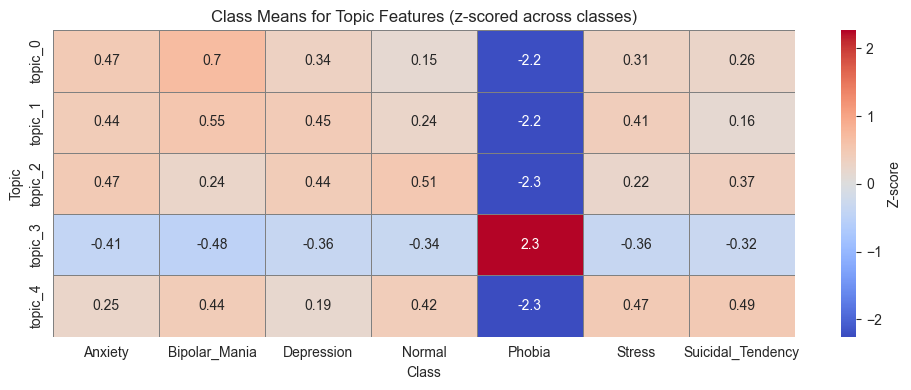


STRUCTURED TEXT SUMMARY
{
  "analysis": "18_topic_analysis",
  "topic_columns": [
    "topic_0",
    "topic_1",
    "topic_2",
    "topic_3",
    "topic_4"
  ],
  "dominant_topic_per_class": {
    "Anxiety": "topic_0",
    "Bipolar_Mania": "topic_0",
    "Depression": "topic_1",
    "Normal": "topic_3",
    "Phobia": "topic_3",
    "Stress": "topic_4",
    "Suicidal_Tendency": "topic_4"
  },
  "z_scored_class_means": {
    "topic_0": {
      "Anxiety": 0.4722,
      "Bipolar_Mania": 0.6999,
      "Depression": 0.3383,
      "Normal": 0.1542,
      "Phobia": -2.2329,
      "Stress": 0.3127,
      "Suicidal_Tendency": 0.2556
    },
    "topic_1": {
      "Anxiety": 0.4395,
      "Bipolar_Mania": 0.5517,
      "Depression": 0.4492,
      "Normal": 0.242,
      "Phobia": -2.2477,
      "Stress": 0.4057,
      "Suicidal_Tendency": 0.1596
    },
    "topic_2": {
      "Anxiety": 0.4715,
      "Bipolar_Mania": 0.2413,
      "Depression": 0.441,
      "Normal": 0.5081,
      "Phobia": -2.2537

In [24]:
# Cell 19: Topic Feature Analysis per Class

if TOPIC_COLS:
    # Overall topic means
    topic_means = df.groupby(TARGET_COL)[TOPIC_COLS].mean()
    
    # Dominant topic per class
    dominant_topic = {cls: topic_means.loc[cls].idxmax() for cls in CLASSES}
    
    # Z-scored class means (across classes for each topic)
    topic_z = (topic_means - topic_means.mean()) / (topic_means.std() + 1e-9)
    topic_z_dict = topic_z.round(4).to_dict()
    
    # Per-topic statistics (global + by class)
    per_topic_stats = {}
    for topic in TOPIC_COLS:
        per_topic_stats[topic] = {
            "global_mean": round(float(df[topic].mean()), 6),
            "global_std": round(float(df[topic].std()), 6),
            "by_class": df.groupby(TARGET_COL)[topic].agg(['mean', 'std', 'min', 'max']).round(6).to_dict()
        }
    
    # ---- Visualisation: heatmap of z-scored class means ----
    plt.figure(figsize=(10, max(4, len(TOPIC_COLS)*0.5)))
    sns.heatmap(topic_z.T, annot=True, cmap='coolwarm', center=0,
                linewidths=0.5, linecolor='gray', cbar_kws={'label': 'Z-score'})
    plt.title('Class Means for Topic Features (z-scored across classes)')
    plt.xlabel('Class')
    plt.ylabel('Topic')
    plt.tight_layout()
    plt.show()

    # ---- Structured Text Summary ----
    topic_summary = {
        "analysis": "18_topic_analysis",
        "topic_columns": TOPIC_COLS,
        "dominant_topic_per_class": dominant_topic,
        "z_scored_class_means": topic_z_dict,
        "per_topic_stats": per_topic_stats
    }
else:
    topic_summary = {
        "analysis": "18_topic_analysis",
        "note": "No topic columns found."
    }

print("\n" + "="*80)
print("STRUCTURED TEXT SUMMARY")
print("="*80)
print(json.dumps(topic_summary, indent=2))

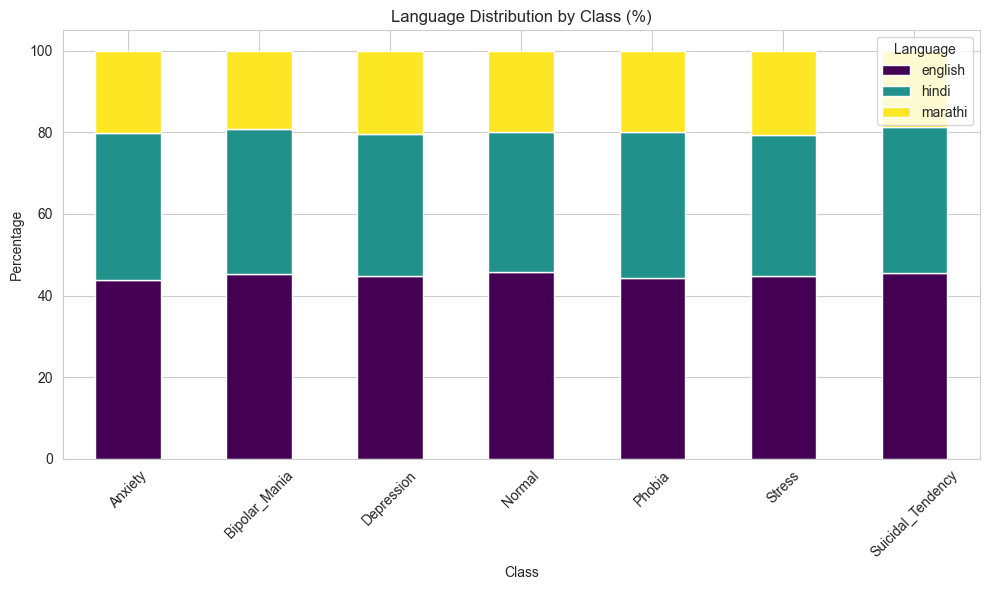


STRUCTURED TEXT SUMMARY
{
  "analysis": "19_language_distribution",
  "overall_language_counts": {
    "english": 22396,
    "hindi": 17625,
    "marathi": 9979
  },
  "counts_by_class": {
    "english": {
      "Anxiety": 3957,
      "Bipolar_Mania": 3083,
      "Depression": 5043,
      "Normal": 2277,
      "Phobia": 1965,
      "Stress": 4038,
      "Suicidal_Tendency": 2033
    },
    "hindi": {
      "Anxiety": 3248,
      "Bipolar_Mania": 2428,
      "Depression": 3945,
      "Normal": 1709,
      "Phobia": 1588,
      "Stress": 3112,
      "Suicidal_Tendency": 1595
    },
    "marathi": {
      "Anxiety": 1819,
      "Bipolar_Mania": 1307,
      "Depression": 2293,
      "Normal": 991,
      "Phobia": 886,
      "Stress": 1850,
      "Suicidal_Tendency": 833
    }
  },
  "proportions_pct_by_class": {
    "english": {
      "Anxiety": 43.85,
      "Bipolar_Mania": 45.22,
      "Depression": 44.7,
      "Normal": 45.75,
      "Phobia": 44.27,
      "Stress": 44.87,
      "Suicid

In [25]:
# Cell 20: Language Distribution (if 'language' column exists)

if 'language' in df.columns:
    # Overall counts
    lang_overall = df['language'].value_counts().to_dict()

    # Counts by class
    lang_by_class = df.groupby([TARGET_COL, 'language']).size().unstack(fill_value=0)
    # Proportions (percentage) by class
    lang_pct = (lang_by_class.div(lang_by_class.sum(axis=1), axis=0) * 100).round(2)

    # ---- Visualisation: stacked bar chart of language proportions ----
    lang_pct.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
    plt.title('Language Distribution by Class (%)')
    plt.xlabel('Class')
    plt.ylabel('Percentage')
    plt.legend(title='Language')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # ---- Structured Text Summary ----
    lang_summary = {
        "analysis": "19_language_distribution",
        "overall_language_counts": lang_overall,
        "counts_by_class": lang_by_class.to_dict(),
        "proportions_pct_by_class": lang_pct.to_dict()
    }
else:
    lang_summary = {
        "analysis": "19_language_distribution",
        "note": "'language' column not present in dataset"
    }

print("\n" + "="*80)
print("STRUCTURED TEXT SUMMARY")
print("="*80)
print(json.dumps(lang_summary, indent=2))

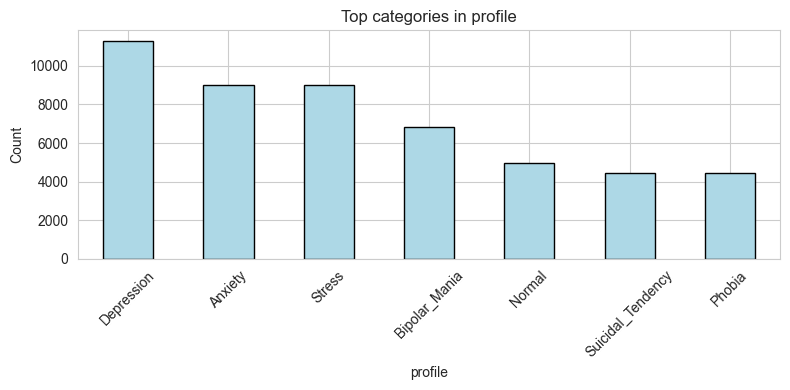

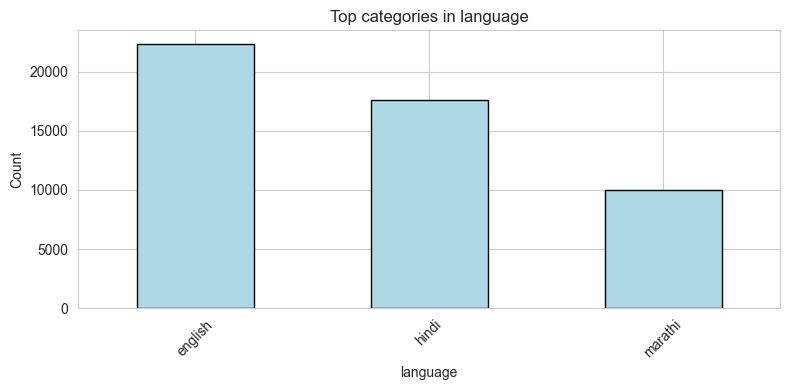


STRUCTURED TEXT SUMMARY
{
  "analysis": "20_categorical_analysis",
  "results": {
    "profile": {
      "n_unique": 7,
      "top_20_values": {
        "Depression": 11281,
        "Anxiety": 9024,
        "Stress": 9000,
        "Bipolar_Mania": 6818,
        "Normal": 4977,
        "Suicidal_Tendency": 4461,
        "Phobia": 4439
      },
      "null_count": 0,
      "cross_tab_by_class": {
        "Anxiety": {
          "Anxiety": 9024,
          "Bipolar_Mania": 0,
          "Depression": 0,
          "Normal": 0,
          "Phobia": 0,
          "Stress": 0,
          "Suicidal_Tendency": 0
        },
        "Bipolar_Mania": {
          "Anxiety": 0,
          "Bipolar_Mania": 6818,
          "Depression": 0,
          "Normal": 0,
          "Phobia": 0,
          "Stress": 0,
          "Suicidal_Tendency": 0
        },
        "Depression": {
          "Anxiety": 0,
          "Bipolar_Mania": 0,
          "Depression": 11281,
          "Normal": 0,
          "Phobia": 0,
    

In [26]:
# Cell 21: Categorical Columns Analysis

cat_analysis = {}
for col in CAT_COLS:
    vc = df[col].value_counts()
    # Cross-tabulation with target
    cross = df.groupby([TARGET_COL, col]).size().unstack(fill_value=0)

    cat_analysis[col] = {
        "n_unique": int(df[col].nunique()),
        "top_20_values": vc.head(20).to_dict(),
        "null_count": int(df[col].isnull().sum()),
        "cross_tab_by_class": cross.to_dict()
    }

    # ---- Visualisation: bar plot of top categories (if not too many) ----
    if len(vc) <= 20:
        plt.figure(figsize=(8, 4))
        vc.head(20).plot(kind='bar', color='lightblue', edgecolor='black')
        plt.title(f'Top categories in {col}')
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

# If no categorical columns, provide note
if not cat_analysis:
    cat_analysis = {"note": "No categorical columns found."}

# ---- Structured Text Summary ----
cat_summary = {
    "analysis": "20_categorical_analysis",
    "results": cat_analysis
}

print("\n" + "="*80)
print("STRUCTURED TEXT SUMMARY")
print("="*80)
print(json.dumps(cat_summary, indent=2))

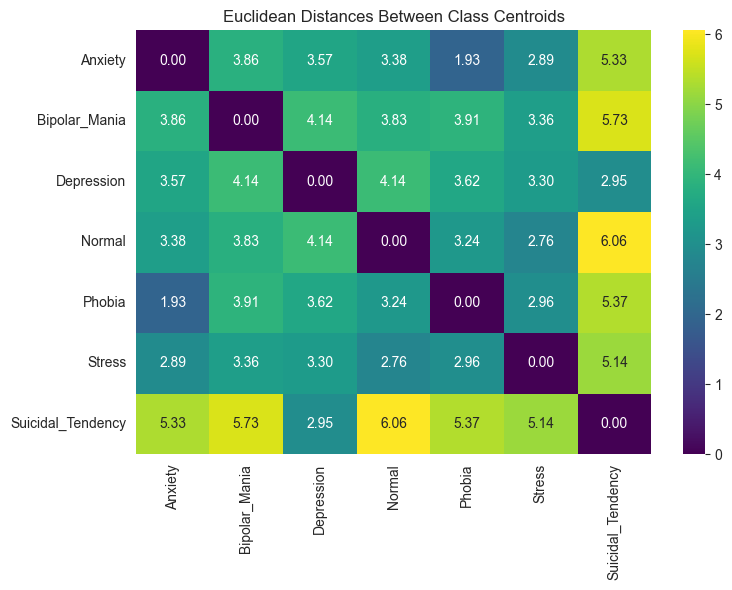


STRUCTURED TEXT SUMMARY
{
  "analysis": "21_class_centroid_distances",
  "features_used": [
    "total_word_count",
    "unique_word_count",
    "ttr",
    "positive_emotion_ratio",
    "negative_emotion_ratio",
    "fear_word_frequency",
    "sadness_word_frequency",
    "anger_word_frequency",
    "uncertainty_word_frequency",
    "filler_word_frequency",
    "repetition_rate",
    "rumination_phrase_frequency",
    "semantic_coherence_score",
    "language_model_perplexity",
    "overall_sentiment_score",
    "past_focus_ratio",
    "present_focus_ratio",
    "future_focus_ratio",
    "noun_ratio",
    "verb_ratio",
    "adjective_ratio",
    "adverb_ratio",
    "avg_sentence_length",
    "parse_tree_depth",
    "topic_shift_frequency",
    "self_reference_density",
    "topic_0",
    "topic_1",
    "topic_2",
    "topic_3",
    "topic_4"
  ],
  "scaling": "StandardScaler",
  "euclidean_pairwise": {
    "Anxiety_vs_Bipolar_Mania": 3.8562,
    "Anxiety_vs_Depression": 3.5674,
    "A

In [27]:
# Cell 22: Class Centroid Distances (on scaled interpretable features)

from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import euclidean_distances, cosine_distances

# Prepare scaled data
X_all = df[INTERP_COLS].fillna(df[INTERP_COLS].median()).values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

# Compute centroids
centroids = {cls: X_scaled[df[TARGET_COL] == cls].mean(axis=0) for cls in CLASSES}
centroid_mat = np.array([centroids[cls] for cls in CLASSES])

# Distance matrices
euc_mat = euclidean_distances(centroid_mat)
cos_mat = cosine_distances(centroid_mat)

# Convert to readable dictionaries
euc_pairs, cos_pairs = {}, {}
for i, ci in enumerate(CLASSES):
    for j, cj in enumerate(CLASSES):
        if i < j:
            key = f"{ci}_vs_{cj}"
            euc_pairs[key] = round(float(euc_mat[i, j]), 4)
            cos_pairs[key] = round(float(cos_mat[i, j]), 4)

# Find most similar/distant pairs
most_similar = min(euc_pairs, key=euc_pairs.get) if euc_pairs else None
most_distant = max(euc_pairs, key=euc_pairs.get) if euc_pairs else None

# ---- Visualisation: heatmap of Euclidean distances ----
plt.figure(figsize=(8, 6))
sns.heatmap(euc_mat, annot=True, fmt='.2f', cmap='viridis',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Euclidean Distances Between Class Centroids')
plt.tight_layout()
plt.show()

# ---- Structured Text Summary ----
centroid_summary = {
    "analysis": "21_class_centroid_distances",
    "features_used": INTERP_COLS,
    "scaling": "StandardScaler",
    "euclidean_pairwise": euc_pairs,
    "cosine_pairwise": cos_pairs,
    "most_similar_pair_euclidean": most_similar,
    "most_distant_pair_euclidean": most_distant,
    "sorted_by_distance": dict(sorted(euc_pairs.items(), key=lambda x: x[1]))
}

print("\n" + "="*80)
print("STRUCTURED TEXT SUMMARY")
print("="*80)
print(json.dumps(centroid_summary, indent=2))

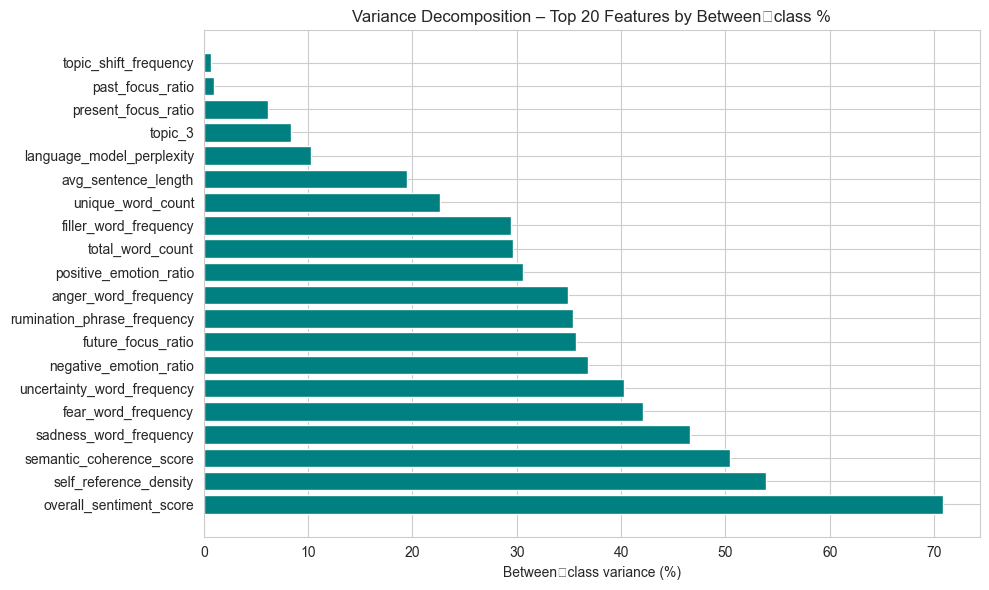


STRUCTURED TEXT SUMMARY
{
  "analysis": "22_feature_variance_decomposition",
  "description": "% of each feature's variance explained by class membership vs within\u2011class spread.",
  "results": {
    "overall_sentiment_score": {
      "total_variance": 0.093352,
      "between_class_var": 0.066148,
      "within_class_var": 0.027204,
      "between_class_pct": 70.86,
      "within_class_pct": 29.14
    },
    "self_reference_density": {
      "total_variance": 0.001688,
      "between_class_var": 0.00091,
      "within_class_var": 0.000778,
      "between_class_pct": 53.9,
      "within_class_pct": 46.1
    },
    "semantic_coherence_score": {
      "total_variance": 0.017955,
      "between_class_var": 0.009058,
      "within_class_var": 0.008896,
      "between_class_pct": 50.45,
      "within_class_pct": 49.55
    },
    "sadness_word_frequency": {
      "total_variance": 0.001498,
      "between_class_var": 0.000698,
      "within_class_var": 0.0008,
      "between_class_pct":

In [28]:
# Cell 23: Feature Variance Decomposition

var_decomp = {}
for feat in INTERP_COLS:
    total_var = df[feat].var()
    if total_var < 1e-15:
        var_decomp[feat] = {
            "total_variance": 0.0,
            "between_class_var": 0.0,
            "within_class_var": 0.0,
            "between_class_pct": 0.0,
            "within_class_pct": 100.0
        }
        continue

    # Compute class-wise counts and means
    cls_counts = df.groupby(TARGET_COL)[feat].count()
    cls_means = df.groupby(TARGET_COL)[feat].mean()
    grand_mean = df[feat].mean()

    # Between-class variance (weighted by class size / total N)
    between = (cls_counts * (cls_means - grand_mean) ** 2).sum() / len(df)
    within = total_var - between

    var_decomp[feat] = {
        "total_variance": round(float(total_var), 6),
        "between_class_var": round(float(between), 6),
        "within_class_var": round(float(within), 6),
        "between_class_pct": round(float(between / total_var * 100), 2),
        "within_class_pct": round(float(within / total_var * 100), 2)
    }

# Sort by between_class_pct descending
var_sorted = dict(sorted(var_decomp.items(), key=lambda x: -x[1]["between_class_pct"]))

# ---- Visualisation: horizontal bar chart of between-class % (top 20) ----
top20_var = list(var_sorted.items())[:20]
feats = [x[0] for x in top20_var]
pct_between = [x[1]['between_class_pct'] for x in top20_var]

plt.figure(figsize=(10, 6))
plt.barh(feats, pct_between, color='teal')
plt.xlabel('Between‑class variance (%)')
plt.title('Variance Decomposition – Top 20 Features by Between‑class %')
plt.tight_layout()
plt.show()

# ---- Structured Text Summary ----
var_summary = {
    "analysis": "22_feature_variance_decomposition",
    "description": "% of each feature's variance explained by class membership vs within‑class spread.",
    "results": var_sorted
}

print("\n" + "="*80)
print("STRUCTURED TEXT SUMMARY")
print("="*80)
print(json.dumps(var_summary, indent=2))

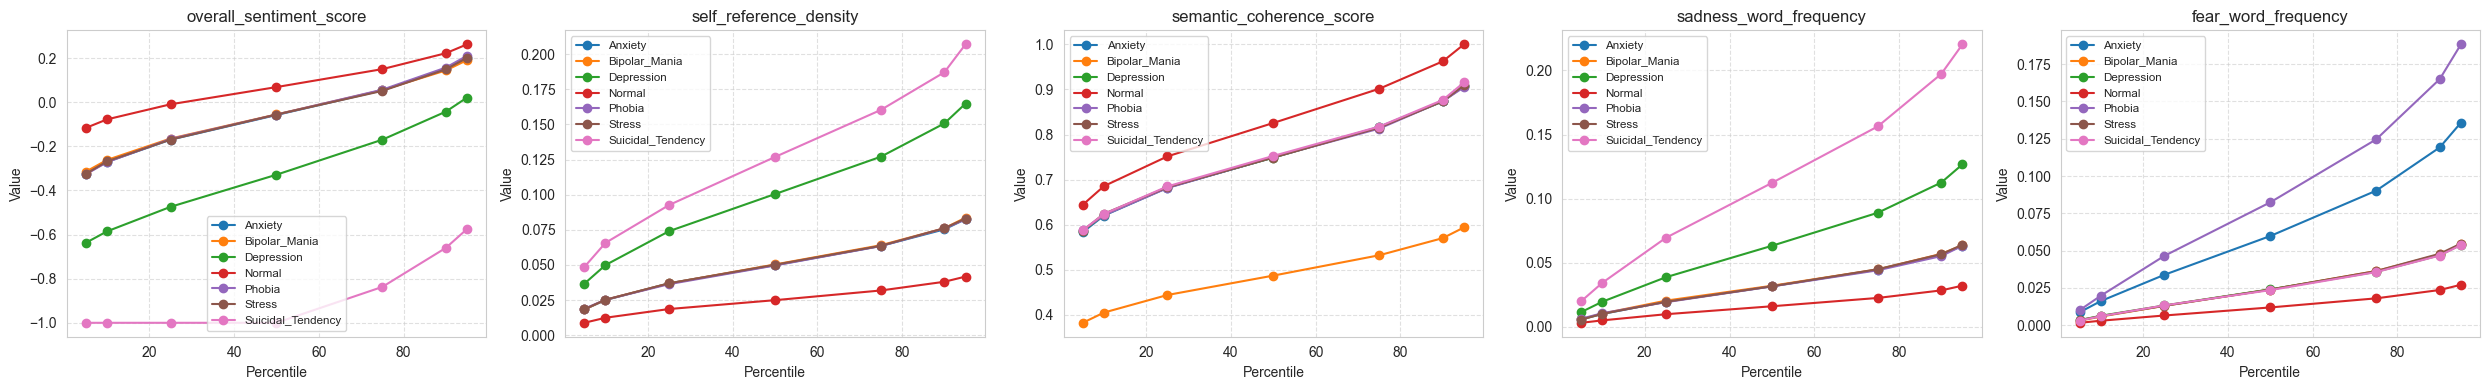


STRUCTURED TEXT SUMMARY
{
  "analysis": "24_percentile_profiles_per_class",
  "percentiles_computed": [
    5,
    10,
    25,
    50,
    75,
    90,
    95
  ],
  "features": [
    "total_word_count",
    "unique_word_count",
    "ttr",
    "positive_emotion_ratio",
    "negative_emotion_ratio",
    "fear_word_frequency",
    "sadness_word_frequency",
    "anger_word_frequency",
    "uncertainty_word_frequency",
    "filler_word_frequency",
    "repetition_rate",
    "rumination_phrase_frequency",
    "semantic_coherence_score",
    "language_model_perplexity",
    "overall_sentiment_score",
    "past_focus_ratio",
    "present_focus_ratio",
    "future_focus_ratio",
    "noun_ratio",
    "verb_ratio",
    "adjective_ratio",
    "adverb_ratio",
    "avg_sentence_length",
    "parse_tree_depth",
    "topic_shift_frequency",
    "self_reference_density"
  ],
  "profiles": {
    "Anxiety": {
      "total_word_count": {
        "p5": 119.15,
        "p10": 154.0,
        "p25": 221.0,
 

In [29]:
# Cell 25: Percentile Profiles per Class (Linguistic Features)

PERCENTILES = [5, 10, 25, 50, 75, 90, 95]
ling_features = LING_COLS  # only linguistic, not topics or embeddings

pct_profiles = {}
for cls in CLASSES:
    sub = df[df[TARGET_COL] == cls][ling_features]
    cls_pcts = {}
    for feat in ling_features:
        vals = sub[feat].dropna().values
        if len(vals) == 0:
            cls_pcts[feat] = {f"p{p}": None for p in PERCENTILES}
        else:
            p_vals = np.percentile(vals, PERCENTILES)
            cls_pcts[feat] = {f"p{p}": round(float(p_vals[i]), 4) for i, p in enumerate(PERCENTILES)}
    pct_profiles[cls] = cls_pcts

# ---- Visualisation: show percentiles for a few key features ----
# We'll pick the top 5 discriminative features from consensus
top_disc = ['overall_sentiment_score', 'self_reference_density', 'semantic_coherence_score',
            'sadness_word_frequency', 'fear_word_frequency']
top_disc = [f for f in top_disc if f in ling_features]

if top_disc:
    n_feat = len(top_disc)
    fig, axes = plt.subplots(nrows=1, ncols=n_feat, figsize=(5*n_feat, 4))
    if n_feat == 1:
        axes = [axes]

    for ax, feat in zip(axes, top_disc):
        for cls in CLASSES:
            p_vals = [pct_profiles[cls][feat][f"p{p}"] for p in PERCENTILES]
            ax.plot(PERCENTILES, p_vals, marker='o', label=cls)
        ax.set_title(feat)
        ax.set_xlabel('Percentile')
        ax.set_ylabel('Value')
        ax.legend(fontsize='small')
        ax.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
else:
    print("No top discriminative features available for percentile plotting.")

# ---- Structured Text Summary ----
percentile_summary = {
    "analysis": "24_percentile_profiles_per_class",
    "percentiles_computed": PERCENTILES,
    "features": ling_features,
    "profiles": pct_profiles
}

print("\n" + "="*80)
print("STRUCTURED TEXT SUMMARY")
print("="*80)
print(json.dumps(percentile_summary, indent=2))

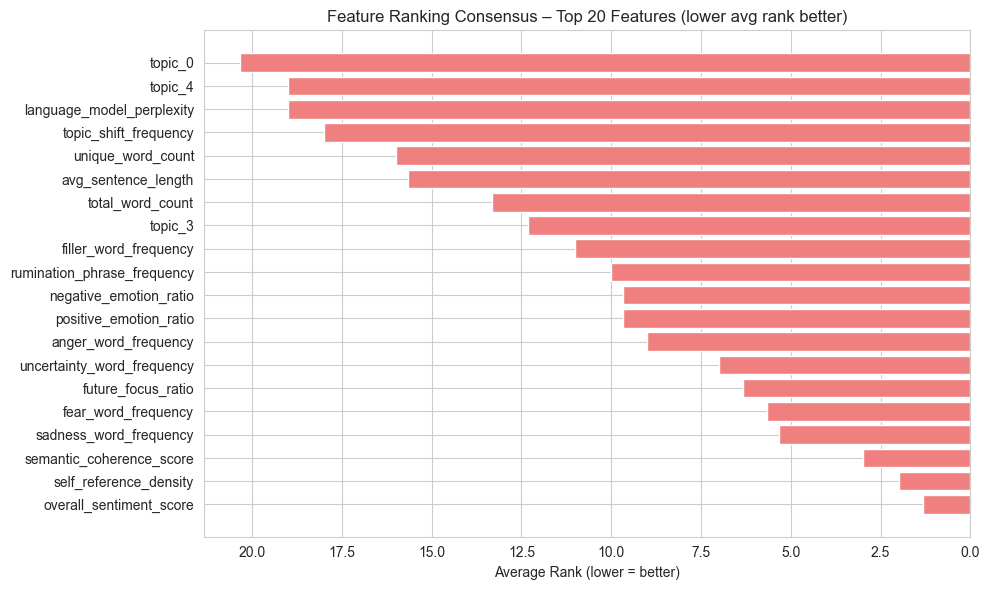


STRUCTURED TEXT SUMMARY
{
  "analysis": "25_feature_ranking_consensus",
  "description": "Consensus rank = average of Kruskal-Wallis, Random Forest MDI, and Mutual Information ranks.",
  "top_10_features": [
    "overall_sentiment_score",
    "self_reference_density",
    "semantic_coherence_score",
    "sadness_word_frequency",
    "fear_word_frequency",
    "future_focus_ratio",
    "uncertainty_word_frequency",
    "anger_word_frequency",
    "positive_emotion_ratio",
    "negative_emotion_ratio"
  ],
  "full_ranking": [
    {
      "feature": "overall_sentiment_score",
      "kw_rank": 2,
      "rf_rank": 1,
      "mi_rank": 1,
      "avg_rank": 1.33
    },
    {
      "feature": "self_reference_density",
      "kw_rank": 1,
      "rf_rank": 3,
      "mi_rank": 2,
      "avg_rank": 2.0
    },
    {
      "feature": "semantic_coherence_score",
      "kw_rank": 4,
      "rf_rank": 2,
      "mi_rank": 3,
      "avg_rank": 3.0
    },
    {
      "feature": "sadness_word_frequency",
  

In [30]:
# Cell 26: Feature Ranking Consensus

# We already have kw_sorted, rf_imp, mi_series from previous cells.
# Ensure they are available (if not, recompute from saved results).

# If not already in memory, we reload from summaries? But we have them in notebook.
# For safety, we'll assume they exist.

def rank_dict(series_or_dict):
    """Convert a sorted feature list (descending importance) to rank dictionary (rank 1 = highest)."""
    if isinstance(series_or_dict, pd.Series):
        features = series_or_dict.index.tolist()
    elif isinstance(series_or_dict, dict):
        features = list(series_or_dict.keys())
    else:
        features = list(series_or_dict)
    return {feat: i+1 for i, feat in enumerate(features)}

# Generate ranks
kw_rank = rank_dict(kw_sorted)
rf_rank = rank_dict(rf_imp)
mi_rank = rank_dict(mi_series)

# Build consensus list
consensus = []
for feat in INTERP_COLS:
    r_kw = kw_rank.get(feat, len(INTERP_COLS))
    r_rf = rf_rank.get(feat, len(INTERP_COLS))
    r_mi = mi_rank.get(feat, len(INTERP_COLS))
    avg_rank = (r_kw + r_rf + r_mi) / 3
    consensus.append({
        "feature": feat,
        "kw_rank": r_kw,
        "rf_rank": r_rf,
        "mi_rank": r_mi,
        "avg_rank": round(avg_rank, 2)
    })

# Sort by avg_rank ascending (lower is better)
consensus.sort(key=lambda x: x["avg_rank"])
top10_consensus = [c["feature"] for c in consensus[:10]]

# ---- Visualisation: bar chart of average rank (top 20) ----
top20_consensus = consensus[:20]
feats = [c["feature"] for c in top20_consensus]
avg_ranks = [c["avg_rank"] for c in top20_consensus]

plt.figure(figsize=(10, 6))
plt.barh(feats, avg_ranks, color='lightcoral')
plt.xlabel('Average Rank (lower = better)')
plt.title('Feature Ranking Consensus – Top 20 Features (lower avg rank better)')
plt.gca().invert_xaxis()  # so best features are on top
plt.tight_layout()
plt.show()

# ---- Structured Text Summary ----
consensus_summary = {
    "analysis": "25_feature_ranking_consensus",
    "description": "Consensus rank = average of Kruskal-Wallis, Random Forest MDI, and Mutual Information ranks.",
    "top_10_features": top10_consensus,
    "full_ranking": consensus
}

print("\n" + "="*80)
print("STRUCTURED TEXT SUMMARY")
print("="*80)
print(json.dumps(consensus_summary, indent=2))

In [31]:
# Cell 27: Master Summary Report

# Collect key pieces from previous analyses
# (Many of these are already stored in variables, but we need to be careful they exist.
#  We'll recreate minimal summaries from the outputs we have.)

master = {
    "project": "Mental Health Synthetic Dataset EDA",
    "dataset_file": "mental_health_synthetic_dataset_with_normal.csv",
    "analysis_date": str(pd.Timestamp.today().date()),
    "dataset": {
        "rows": df.shape[0],
        "columns": df.shape[1],
        "classes": CLASSES,
        "n_classes": len(CLASSES),
        "class_counts": df[TARGET_COL].value_counts().to_dict(),
        "imbalance_ratio": round(df[TARGET_COL].value_counts().max() / df[TARGET_COL].value_counts().min(), 4),
        "total_null_cells": int(df.isnull().sum().sum()),
        "duplicate_rows": int(df.duplicated().sum()),
        "memory_mb": round(df.memory_usage(deep=True).sum() / 1024**2, 2)
    },
    "feature_groups": {
        "linguistic": len(LING_COLS),
        "topic": len(TOPIC_COLS),
        "embedding": len(EMB_COLS),
        "categorical": len(CAT_COLS)
    },
    "statistical_tests": {
        "kruskal_wallis": {
            "n_features_tested": len(kw_results),
            "n_significant_p05": sum(1 for v in kw_results.values() if v["significant"]),
            "top_10_by_H": list(kw_sorted.keys())[:10]
        },
        "anova": {
            "n_significant_p05": sum(1 for v in anova_results.values() if v["significant"])
        },
        "eta_squared": {
            "n_large_effect": effect_counts["large"],
            "n_medium_effect": effect_counts["medium"],
            "n_small_effect": effect_counts["small"]
        }
    },
    "feature_importance": {
        "top_10_kruskal_wallis": list(kw_sorted.keys())[:10],
        "top_10_random_forest": list(rf_imp.head(10).index),
        "top_10_mutual_info": list(mi_series.head(10).index),
        "top_10_consensus": top10_consensus
    },
    "correlations": {
        "n_highly_correlated_pairs": len(pairs) if 'pairs' in locals() else 0,
        "threshold": CORR_HIGH_THRESHOLD if 'CORR_HIGH_THRESHOLD' in locals() else 0.75
    },
    "class_separability": {
        "most_similar_pair_euclidean": most_similar if 'most_similar' in locals() else None,
        "most_distant_pair_euclidean": most_distant if 'most_distant' in locals() else None,
        "top_discriminative_feature": consensus[0]["feature"] if consensus else None
    },
    "pca_insights": {
        "embedding_top10_variance_pct": round(cum_evr[-1] * 100, 2) if 'cum_evr' in locals() and EMB_COLS else None,
        "feat_pca_components_for_80pct": comp_80_feat if 'comp_80_feat' in locals() else None,
        "feat_pca_components_for_90pct": comp_90_feat if 'comp_90_feat' in locals() else None
    },
    "per_class_summary": {
        cls: {
            "n_samples": int((df[TARGET_COL] == cls).sum()),
            "pct_of_dataset": round((df[TARGET_COL] == cls).sum() / len(df) * 100, 2),
            "top_feature_mean": {
                feat: round(float(df[df[TARGET_COL] == cls][feat].mean()), 4)
                for feat in top10_consensus[:5]
            }
        }
        for cls in CLASSES
    }
}

# ---- Final Structured Summary ----
print("\n" + "="*80)
print("MASTER SUMMARY REPORT")
print("="*80)
print(json.dumps(master, indent=2))
print("\n" + "="*80)
print("EDA COMPLETE")
print("="*80)


MASTER SUMMARY REPORT
{
  "project": "Mental Health Synthetic Dataset EDA",
  "dataset_file": "mental_health_synthetic_dataset_with_normal.csv",
  "analysis_date": "2026-03-10",
  "dataset": {
    "rows": 50000,
    "columns": 66,
    "classes": [
      "Anxiety",
      "Bipolar_Mania",
      "Depression",
      "Normal",
      "Phobia",
      "Stress",
      "Suicidal_Tendency"
    ],
    "n_classes": 7,
    "class_counts": {
      "Depression": 11281,
      "Anxiety": 9024,
      "Stress": 9000,
      "Bipolar_Mania": 6818,
      "Normal": 4977,
      "Suicidal_Tendency": 4461,
      "Phobia": 4439
    },
    "imbalance_ratio": 2.5413,
    "total_null_cells": 0,
    "duplicate_rows": 0,
    "memory_mb": 32.2
  },
  "feature_groups": {
    "linguistic": 26,
    "topic": 5,
    "embedding": 32,
    "categorical": 2
  },
  "statistical_tests": {
    "kruskal_wallis": {
      "n_features_tested": 31,
      "n_significant_p05": 24,
      "top_10_by_H": [
        "self_reference_density",